# Mass Model — $\mathcal{P}(P_\mathrm{rot}\,|\,m, \sigma_m, \tau)$


Flow $x$ (density variable): `log_prot`  
Conditioning vector: `[log_age_myr, mass_msun, mass_msun_err_lo, mass_msun_err_hi]`  

In [12]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import pandas as pd
import torch
import pickle
import matplotlib.pyplot as plt

from training.constants import LOGA_GRID
from training.data      import load_training
from training.kfold     import run_kfold
from training.plots     import set_paper_style, plot_posteriors_by_age
from training.report    import training_report, kfold_report, prot_space_report

set_paper_style()

## 1. Load data

In [13]:
df = load_training('../../cf_data/training_stars.csv', drop_nan_age_err=False)
print(f'Total stars : {len(df)}')
print(f'Sources     : {df["source_paper"].nunique()}')
df[['log_prot', 'log_age_myr', 'mass_msun', 'mass_msun_err_lo', 'mass_msun_err_hi']].describe()

Total stars : 6128
Sources     : 23


,log_prot,log_age_myr,mass_msun,mass_msun_err_lo,mass_msun_err_hi
count,6128.000000,6128.000000,6128.000000,6128.000000,6128.000000
mean,0.279537,2.108153,0.452532,0.018013,0.017654
std,0.568351,0.679351,0.146287,0.014026,0.012270
min,-1.084073,0.176091,0.098083,0.002376,0.002413
25%,-0.148253,1.602060,0.335664,0.010206,0.010417
50%,0.193381,2.123852,0.471818,0.013964,0.014166
75%,0.653831,2.599883,0.578688,0.017915,0.018177
max,2.241546,4.060698,0.673861,0.091214,0.079824


## 1b. Training data age distribution

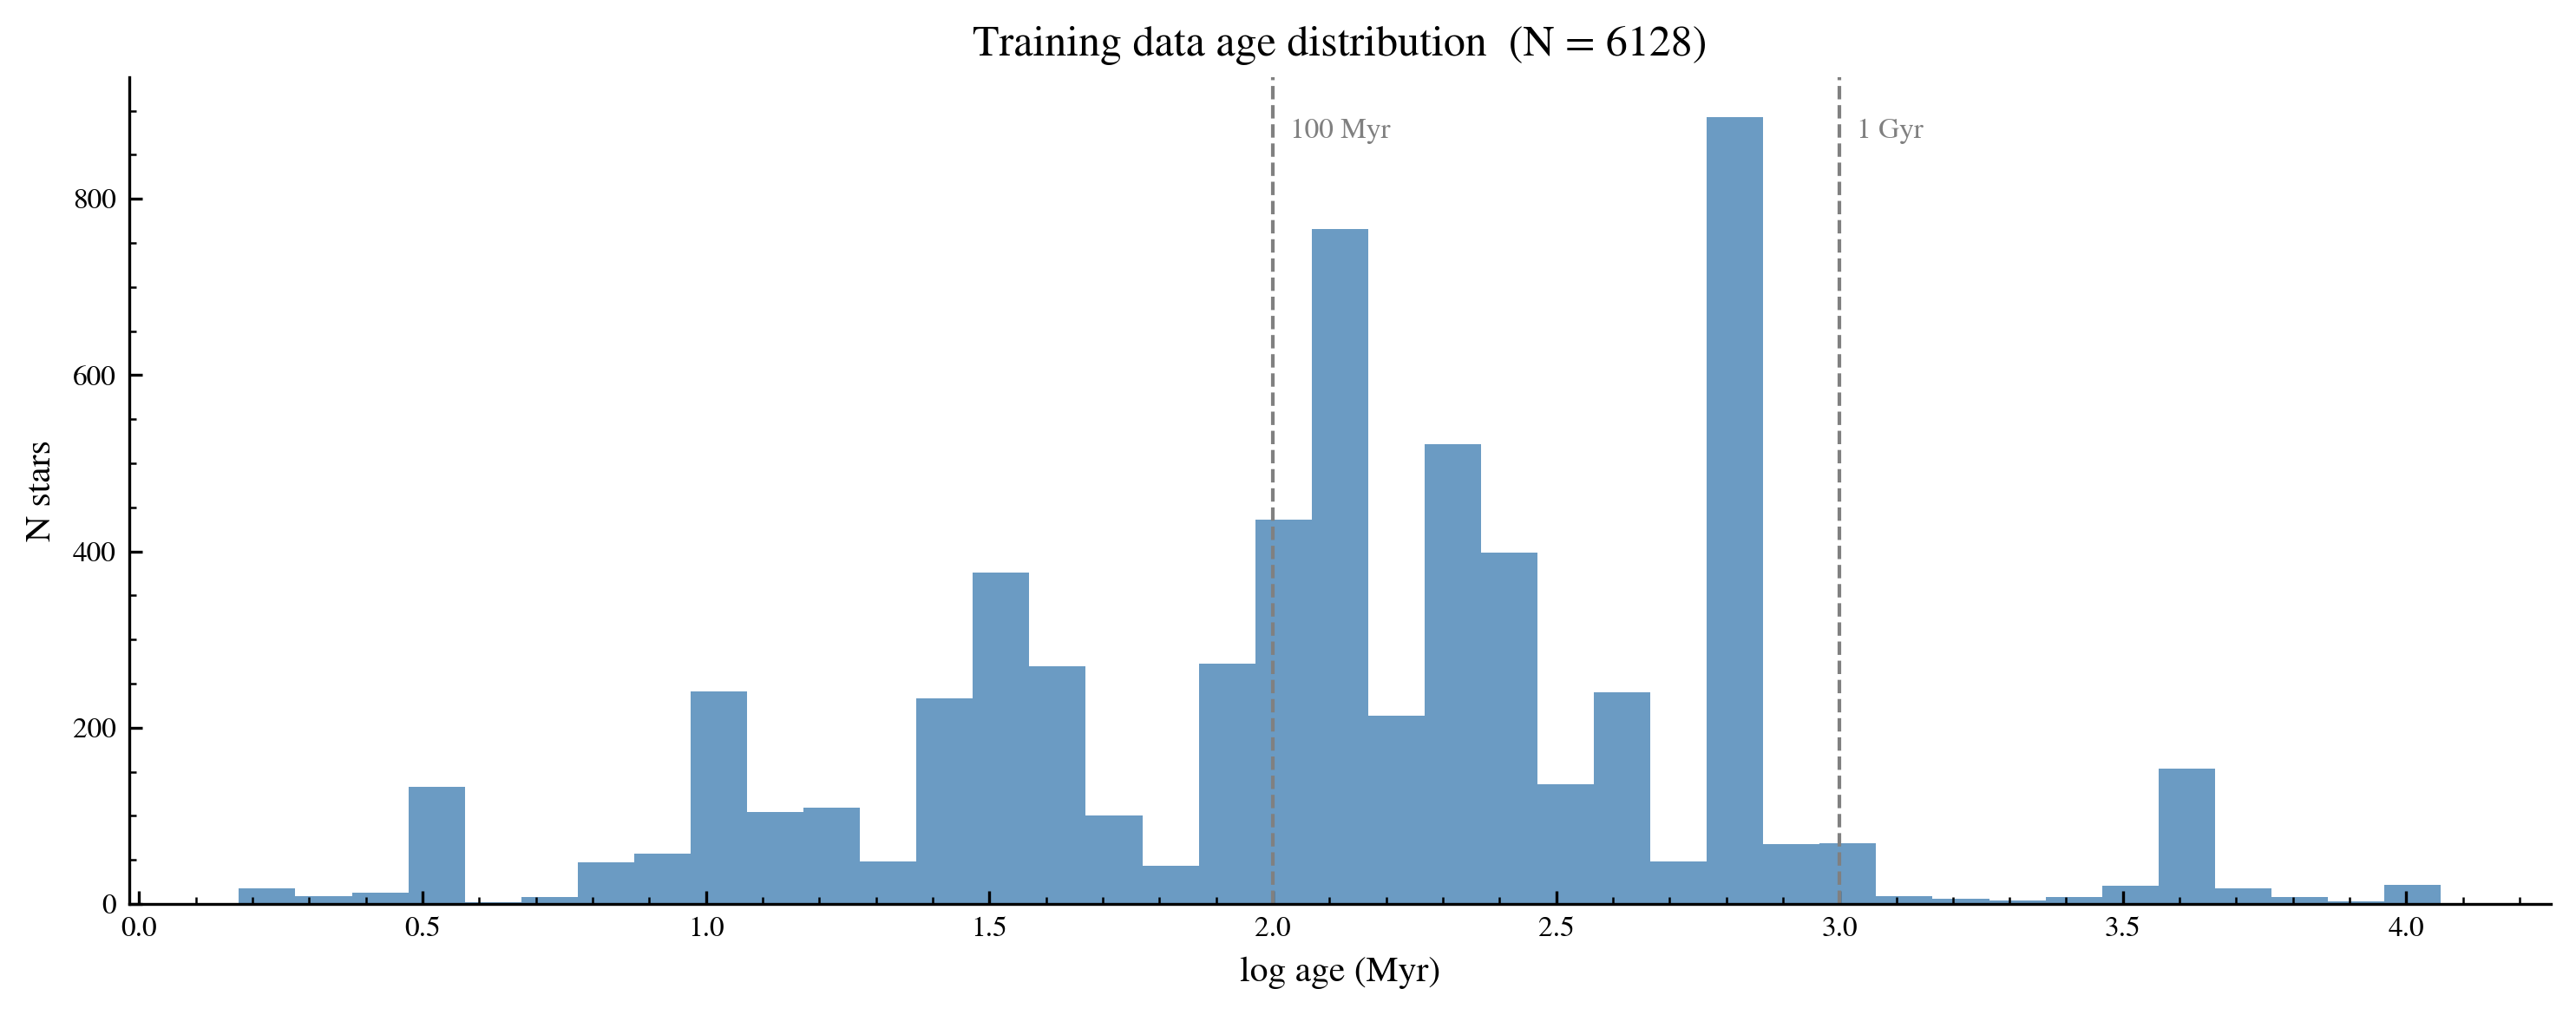

< 100 Myr   : 2313  (37.7%)
100–1000 Myr: 3522  (57.5%)
> 1 Gyr     :  293  (4.8%)


In [40]:
fig, ax = plt.subplots(figsize=(10, 4))
bins = np.linspace(df['log_age_myr'].min(), df['log_age_myr'].max(), 40)

ax.hist(df['log_age_myr'], bins=bins, color='steelblue', alpha=0.8)

ax.axvline(np.log10(100),  color='grey', lw=1, ls='--')
ax.axvline(np.log10(1000), color='grey', lw=1, ls='--')
ax.text(np.log10(100)  + 0.03, ax.get_ylim()[1] * 0.95, '100 Myr', fontsize=8, va='top', color='grey')
ax.text(np.log10(1000) + 0.03, ax.get_ylim()[1] * 0.95, '1 Gyr',   fontsize=8, va='top', color='grey')

ax.set_xlabel('log age (Myr)')
ax.set_ylabel('N stars')
ax.set_title(f'Training data age distribution  (N = {len(df)})')
plt.tight_layout()
plt.show()

print(f'< 100 Myr   : {(df["log_age_myr"] < np.log10(100)).sum():4d}  ({(df["log_age_myr"] < np.log10(100)).mean()*100:.1f}%)')
print(f'100–1000 Myr: {((df["log_age_myr"] >= np.log10(100)) & (df["log_age_myr"] < 3.0)).sum():4d}  ({((df["log_age_myr"] >= np.log10(100)) & (df["log_age_myr"] < 3.0)).mean()*100:.1f}%)')
print(f'> 1 Gyr     : {(df["log_age_myr"] >= 3.0).sum():4d}  ({(df["log_age_myr"] >= 3.0).mean()*100:.1f}%)')

## 2. Define conditioning columns

In [14]:
OBS_COL   = 'log_prot'
COND_COLS = ['log_age_myr', 'mass_msun', 'mass_msun_err_lo', 'mass_msun_err_hi']
N_FOLDS   = 5
STEPS     = 5000

print('Conditioning vector size:', len(COND_COLS))
print('Columns:', COND_COLS)

Conditioning vector size: 4
Columns: ['log_age_myr', 'mass_msun', 'mass_msun_err_lo', 'mass_msun_err_hi']


## 3. K-fold training

In [15]:
results_df, fold_flows, fold_scalers, loss_curves, posteriors_kfold = run_kfold(
    df        = df,
    obs_col   = OBS_COL,
    cond_cols = COND_COLS,
    n_folds   = N_FOLDS,
    steps     = STEPS,
)


=== Fold 1 / 5 ===
step     0  loss 1.537861
step  1000  loss 0.227200
step  2000  loss 0.212558
step  3000  loss 0.205830
step  4000  loss 0.205163
step  5000  loss 0.204836

=== Fold 2 / 5 ===
step     0  loss 1.538220
step  1000  loss 0.214570
step  2000  loss 0.198314
step  3000  loss 0.188799
step  4000  loss 0.187761
step  5000  loss 0.187285

=== Fold 3 / 5 ===
step     0  loss 1.540479
step  1000  loss 0.221217
step  2000  loss 0.205530
step  3000  loss 0.198145
step  4000  loss 0.197261
step  5000  loss 0.196858

=== Fold 4 / 5 ===
step     0  loss 1.539267
step  1000  loss 0.214000
step  2000  loss 0.192783
step  3000  loss 0.184301
step  4000  loss 0.183036
step  5000  loss 0.182456

=== Fold 5 / 5 ===
step     0  loss 1.541959
step  1000  loss 0.220261
step  2000  loss 0.206845
step  3000  loss 0.198540
step  4000  loss 0.197591
step  5000  loss 0.197156


## 4. Training loss

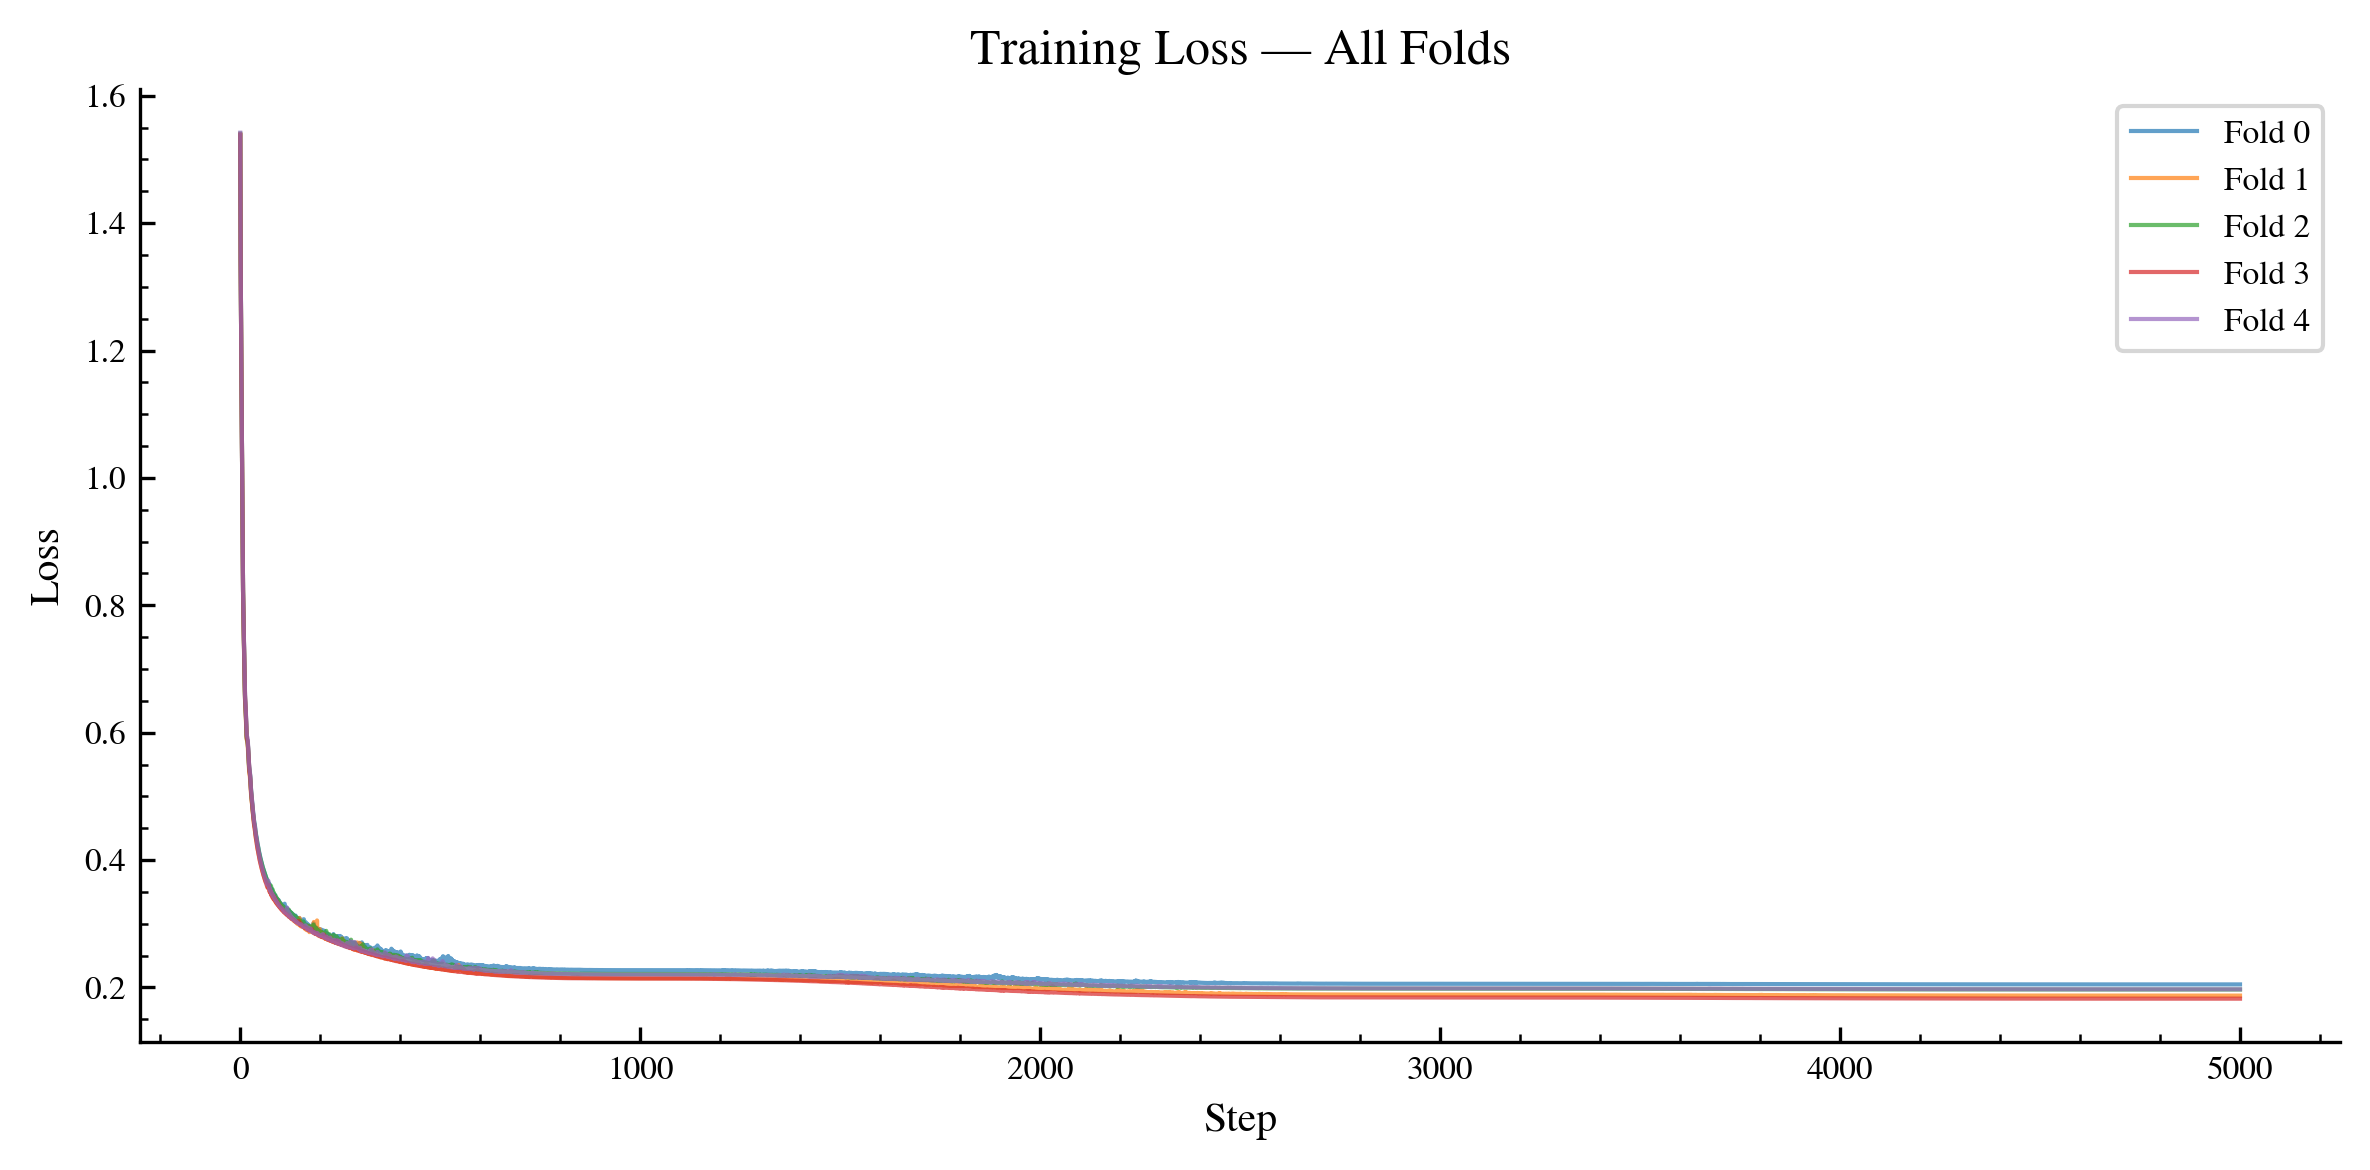

In [16]:
training_report(loss_curves)

## 5. Residual diagnostics

/Users/alanxia/Documents/GitHub/cf_xmatch/training/notebooks/../../training/plots.py:287: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.scatter(xvals, resid, **_kw_scat)


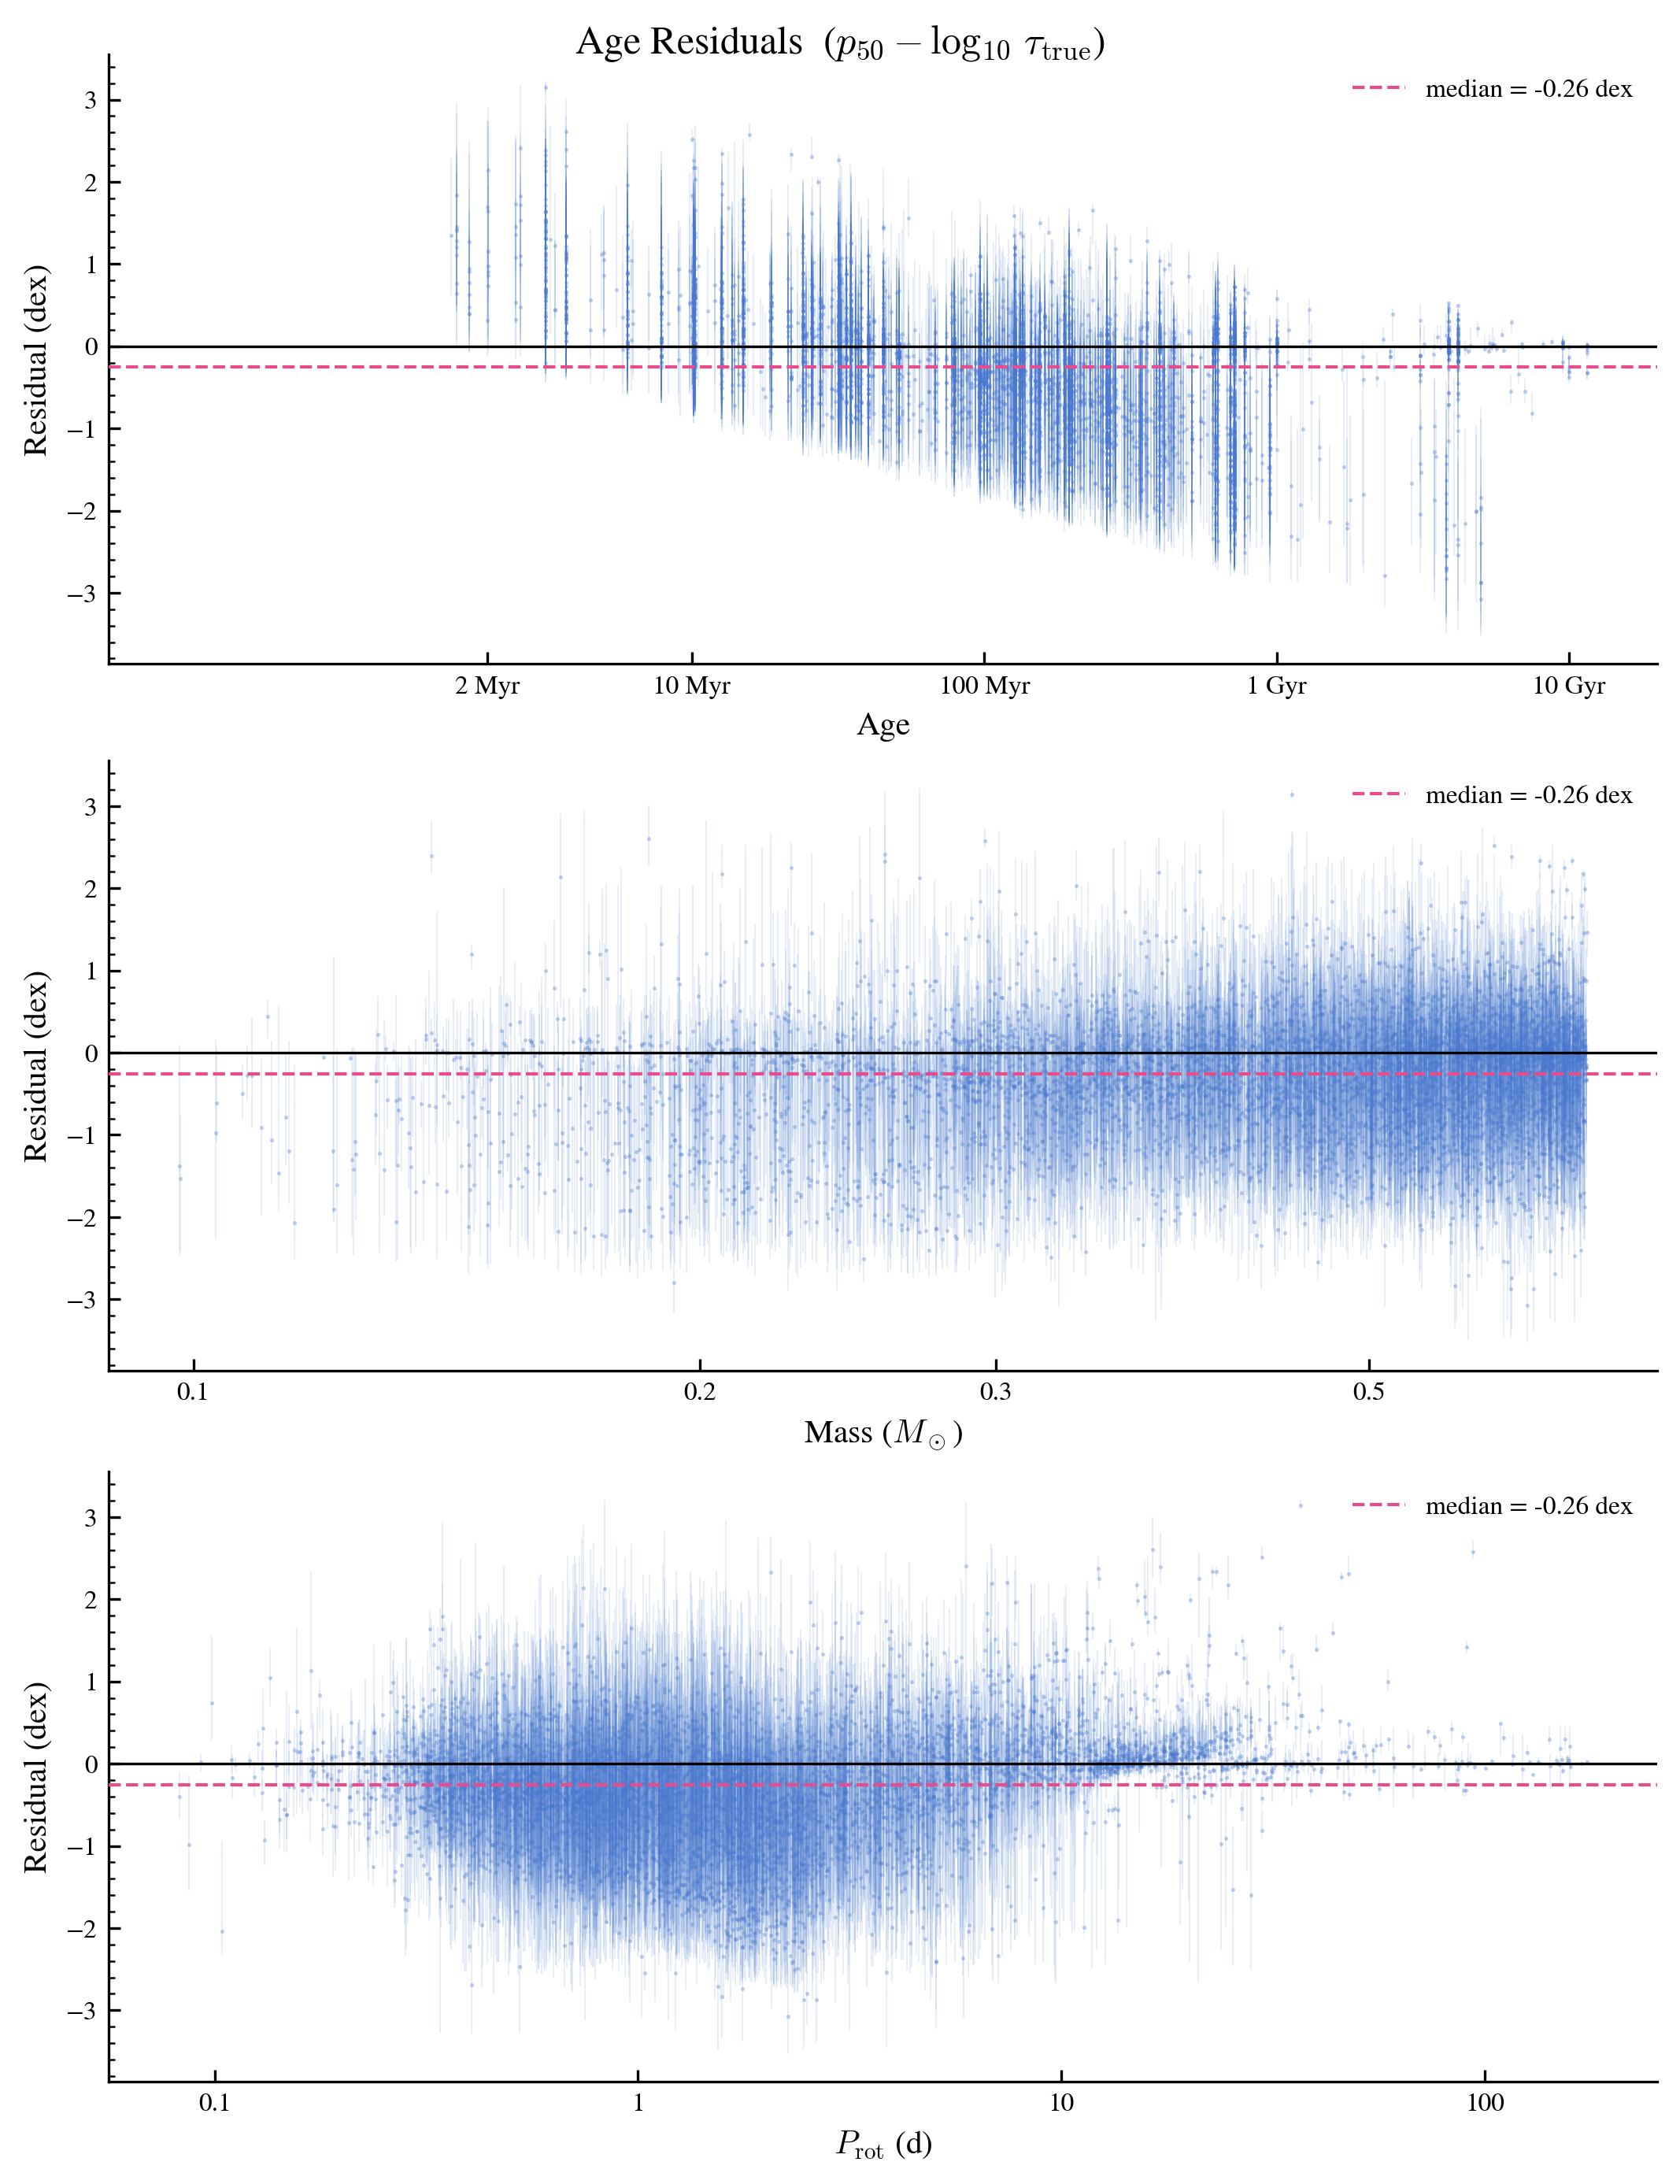

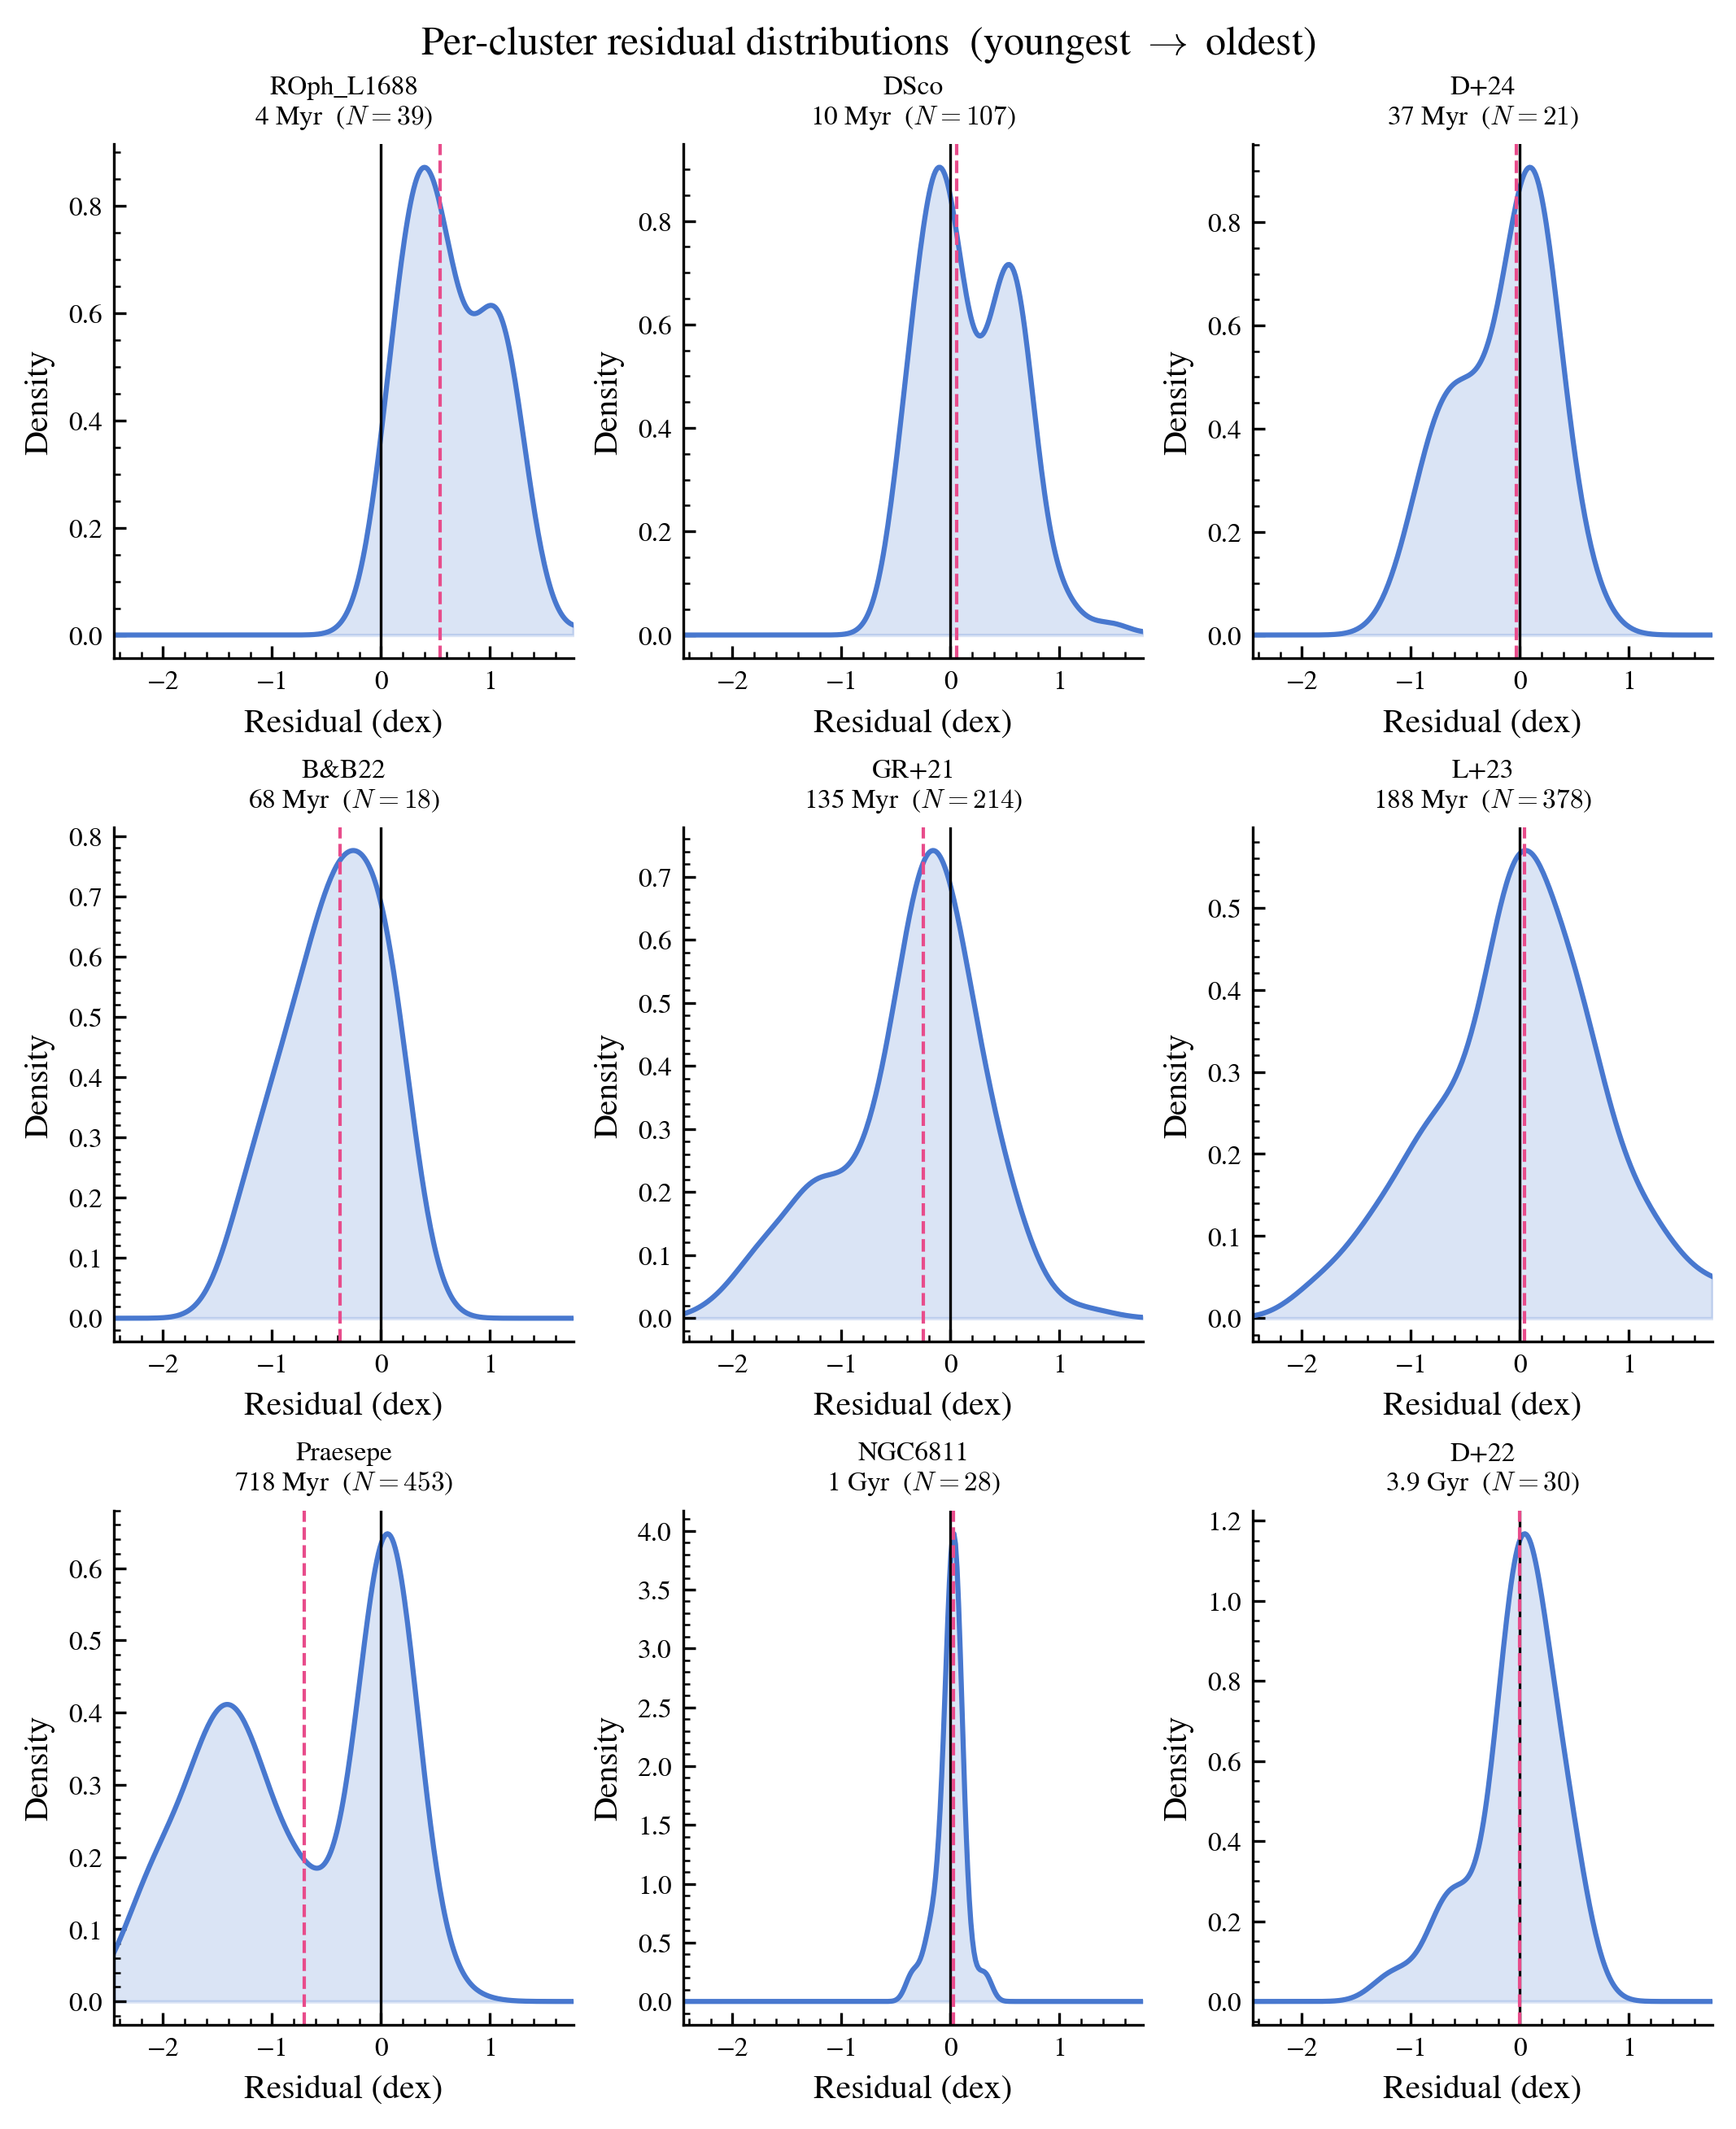

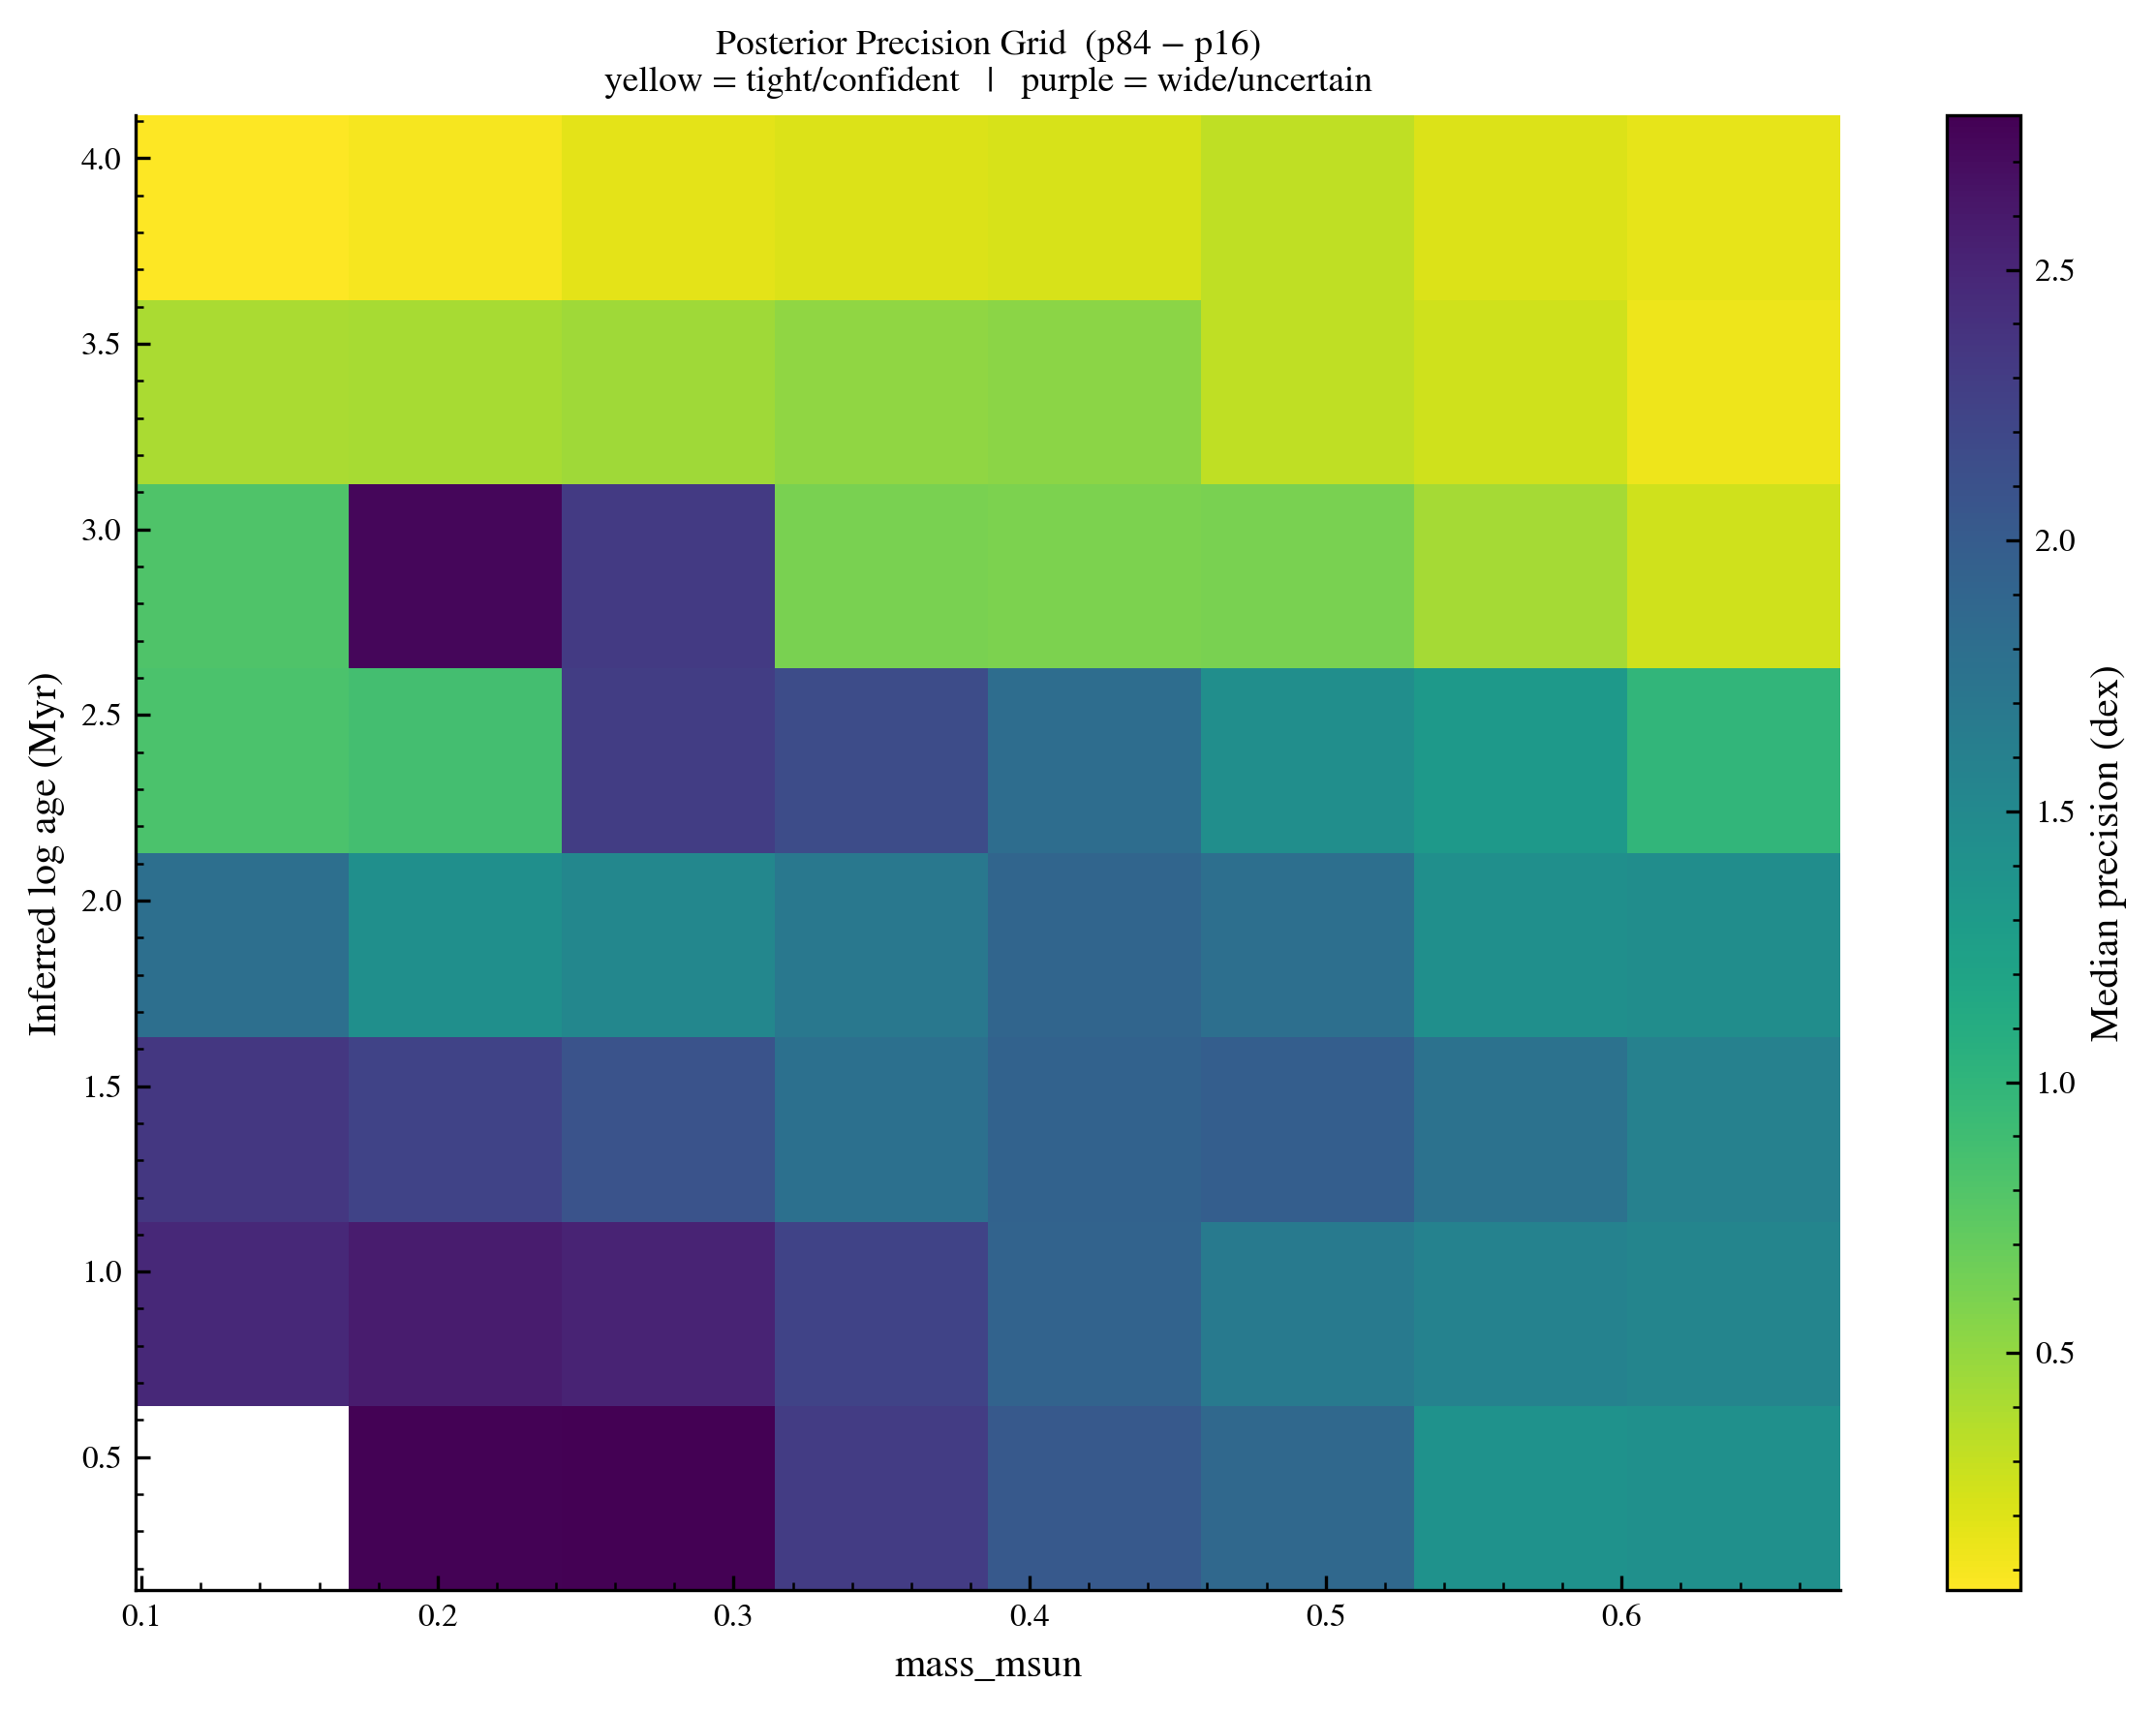

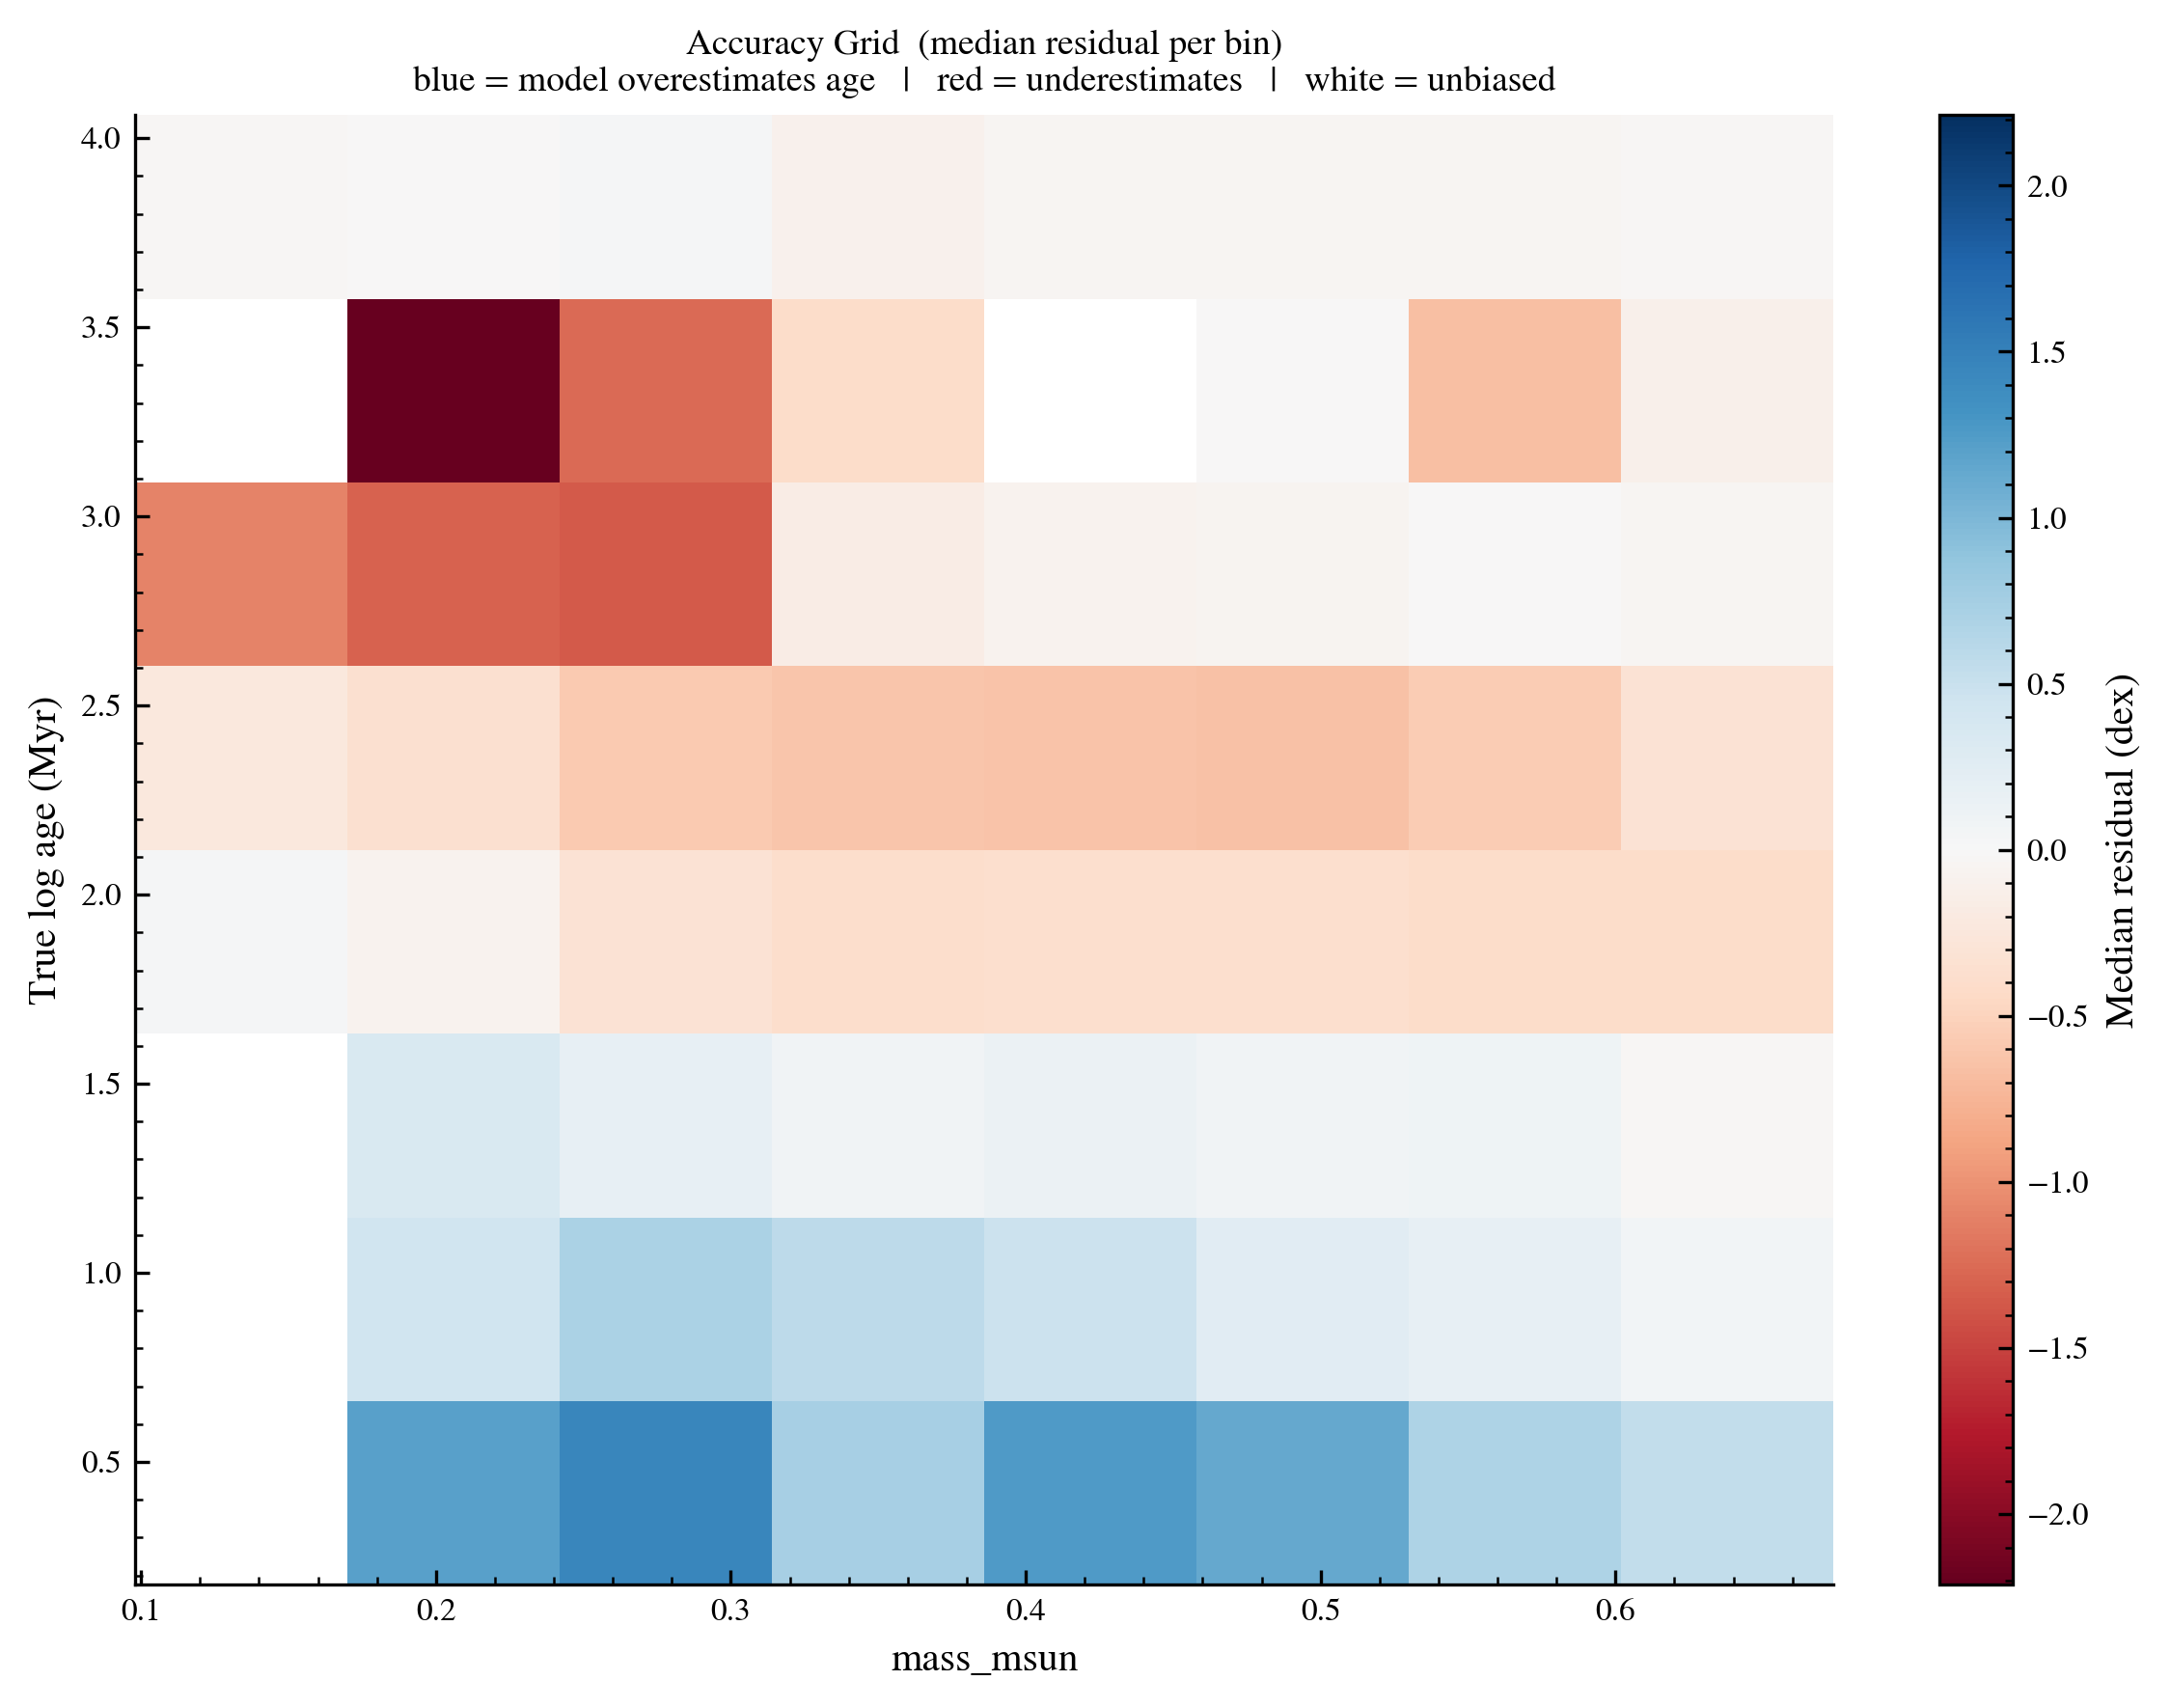

In [37]:
import importlib, training.plots, training.report
importlib.reload(training.plots)
importlib.reload(training.report)
from training.report import kfold_report

kfold_report(results_df)

## 5b. Praesepe posteriors — fast vs slow rotators (~660 Myr)

Praesepe-age cluster stars: 162
source_paper
L+23            70
GR+21           42
F+23            34
R+21            15
Mamonova2025     1


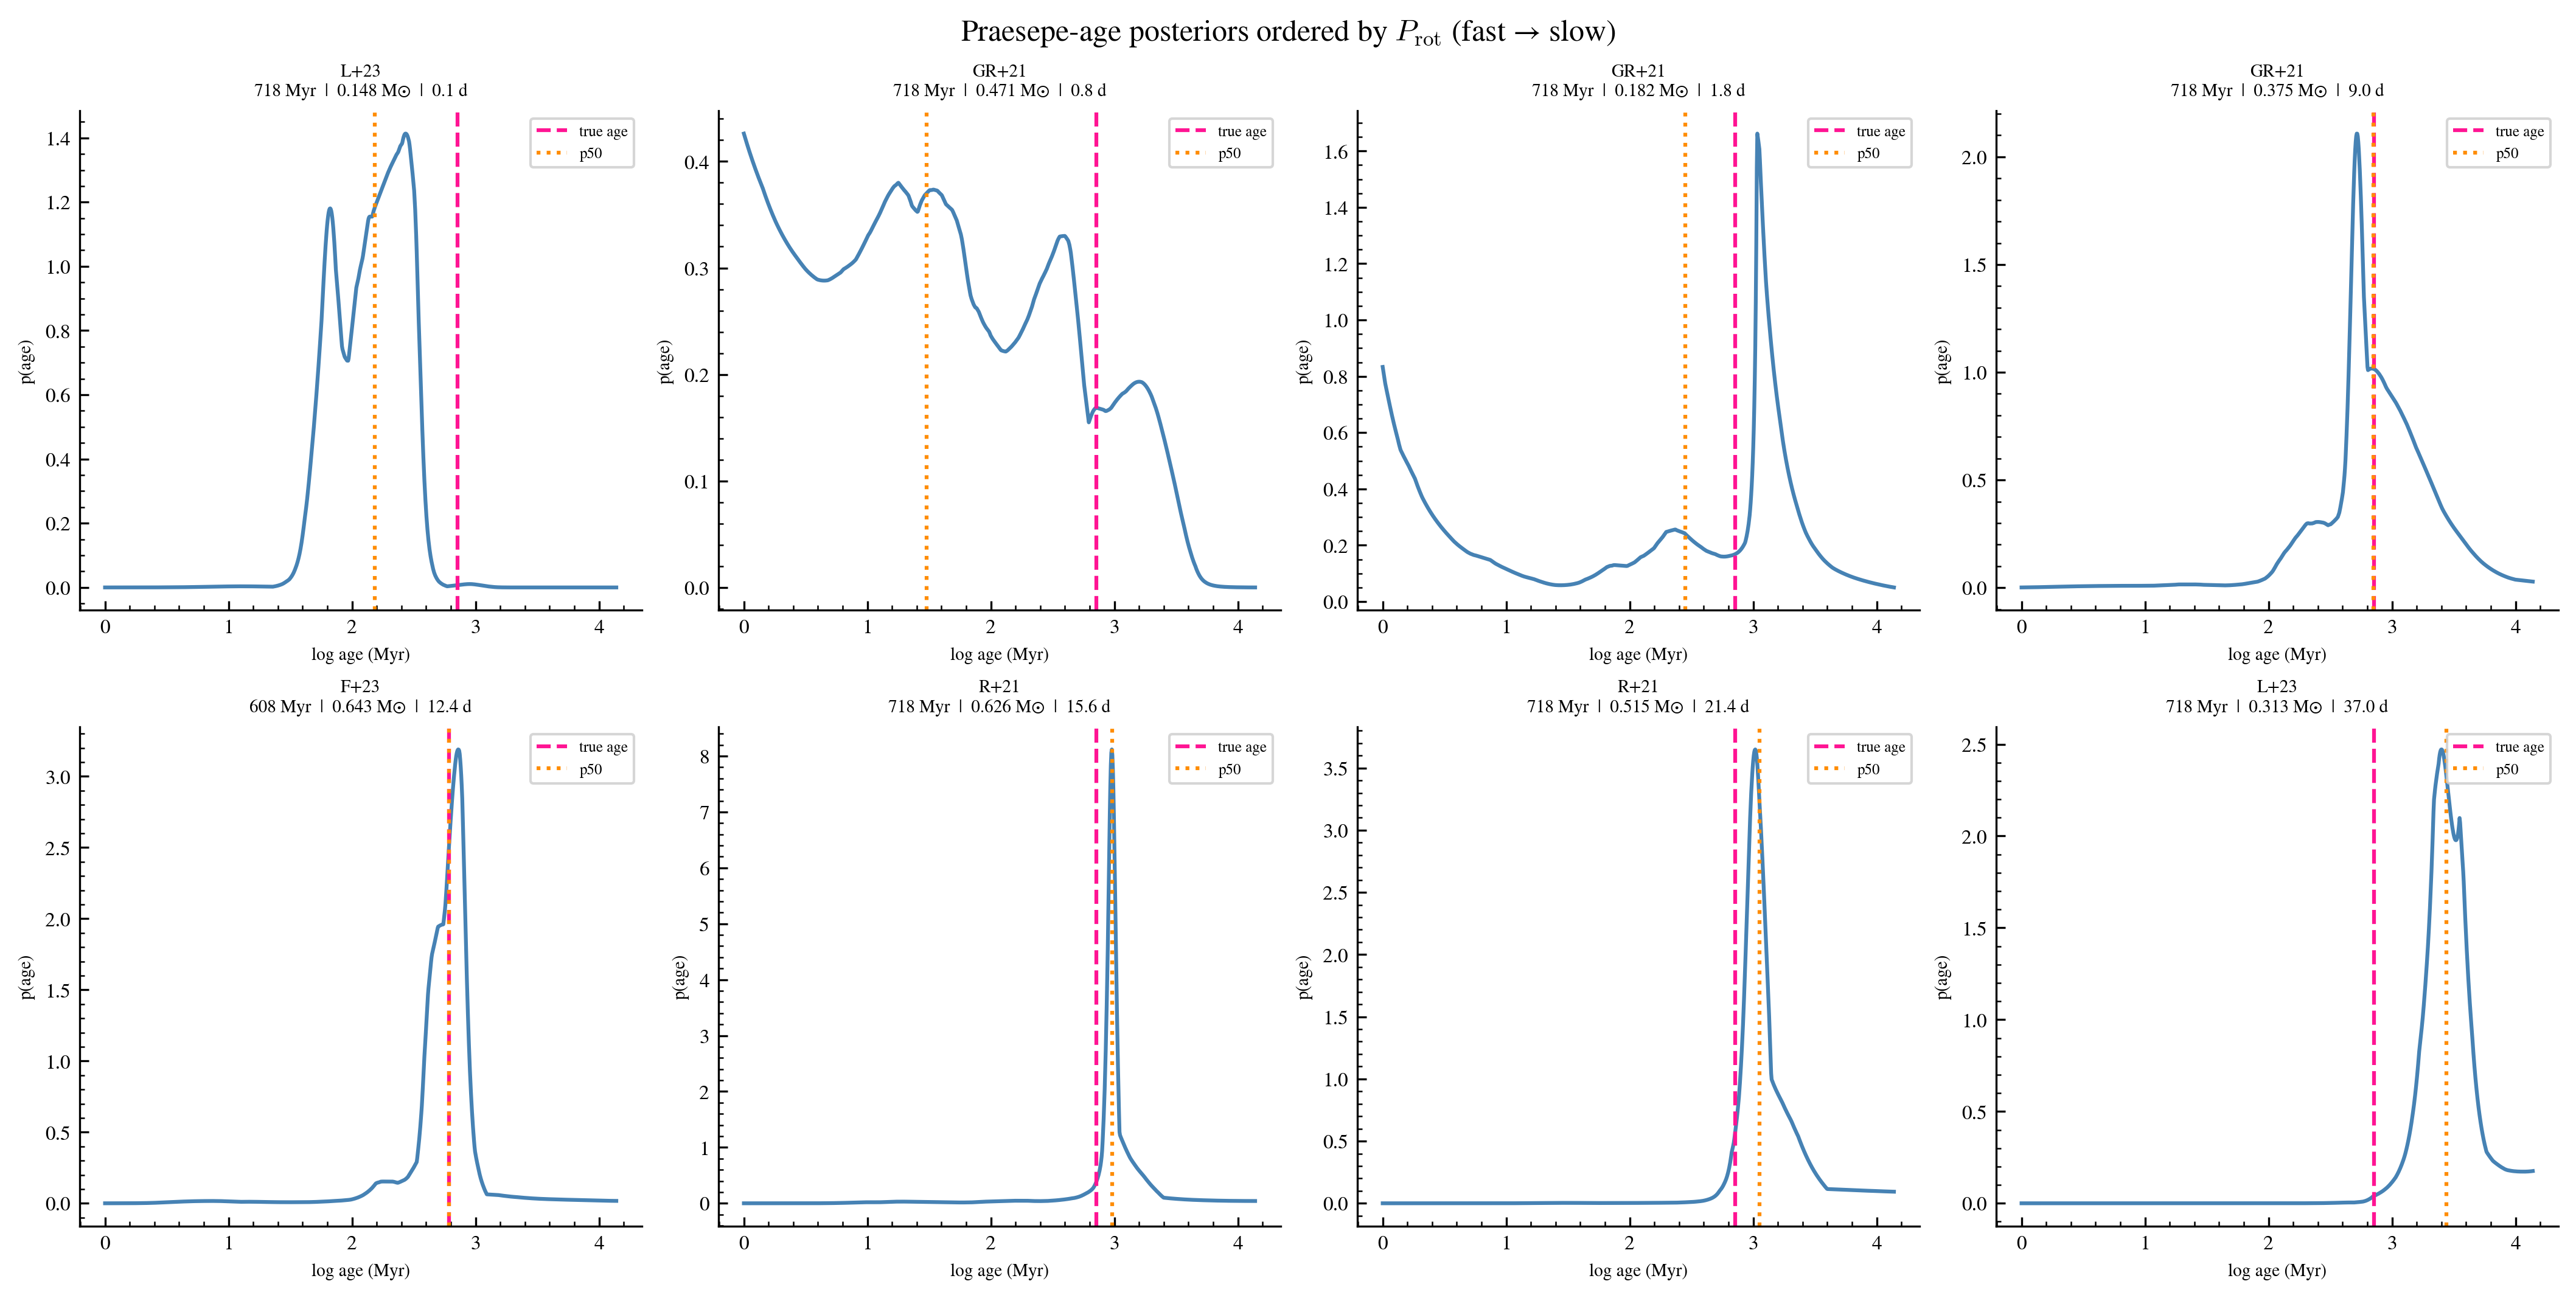

In [44]:
_field = {'MOCADB', 'Engle2023', 'LWRD', 'Pass2022'}

# Praesepe age ~660 Myr (log10(660) ~ 2.82); use L+23 which has the most members
praes_mask = (
    (results_df['log_age_myr'] > 2.77) &
    (results_df['log_age_myr'] < 2.88) &
    ~results_df['source_paper'].isin(_field) &
    (results_df['source_paper'] != 'multi')
)
praes_df  = results_df[praes_mask].copy().reset_index(drop=True)
praes_pos = np.where(praes_mask)[0]

print(f'Praesepe-age cluster stars: {len(praes_df)}')
print(praes_df['source_paper'].value_counts().to_string())

# Pick 8 evenly spaced across the prot_days range (fast → slow)
prot_order = np.argsort(praes_df['prot_days'].values)
pick = prot_order[np.linspace(0, len(prot_order) - 1, 8, dtype=int)]

n_cols, n_rows = 4, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 7), layout='constrained')
axes = axes.flatten()
for ax, i in zip(axes, pick):
    row      = praes_df.iloc[i]
    post_idx = praes_pos[i]
    ax.plot(LOGA_GRID, posteriors_kfold[post_idx], color='steelblue', lw=1.5)
    ax.axvline(row['log_age_myr'], color='deeppink',  lw=1.5, ls='--', label='true age')
    ax.axvline(row['p50'],         color='darkorange', lw=1.5, ls=':',  label='p50')
    ax.set_title(
        f"{row['source_paper']}\n"
        f"{10**row['log_age_myr']:.0f} Myr  |  {row['mass_msun']:.3f} M☉  |  {row['prot_days']:.1f} d",
        fontsize=7,
    )
    ax.set_xlabel('log age (Myr)', fontsize=7)
    ax.set_ylabel('p(age)', fontsize=7)
    ax.legend(fontsize=6)
fig.suptitle('Praesepe-age posteriors ordered by $P_\\mathrm{rot}$ (fast → slow)')
plt.show()

## 6. Sample posteriors by age range

Posteriors shape: (6128, 1000)


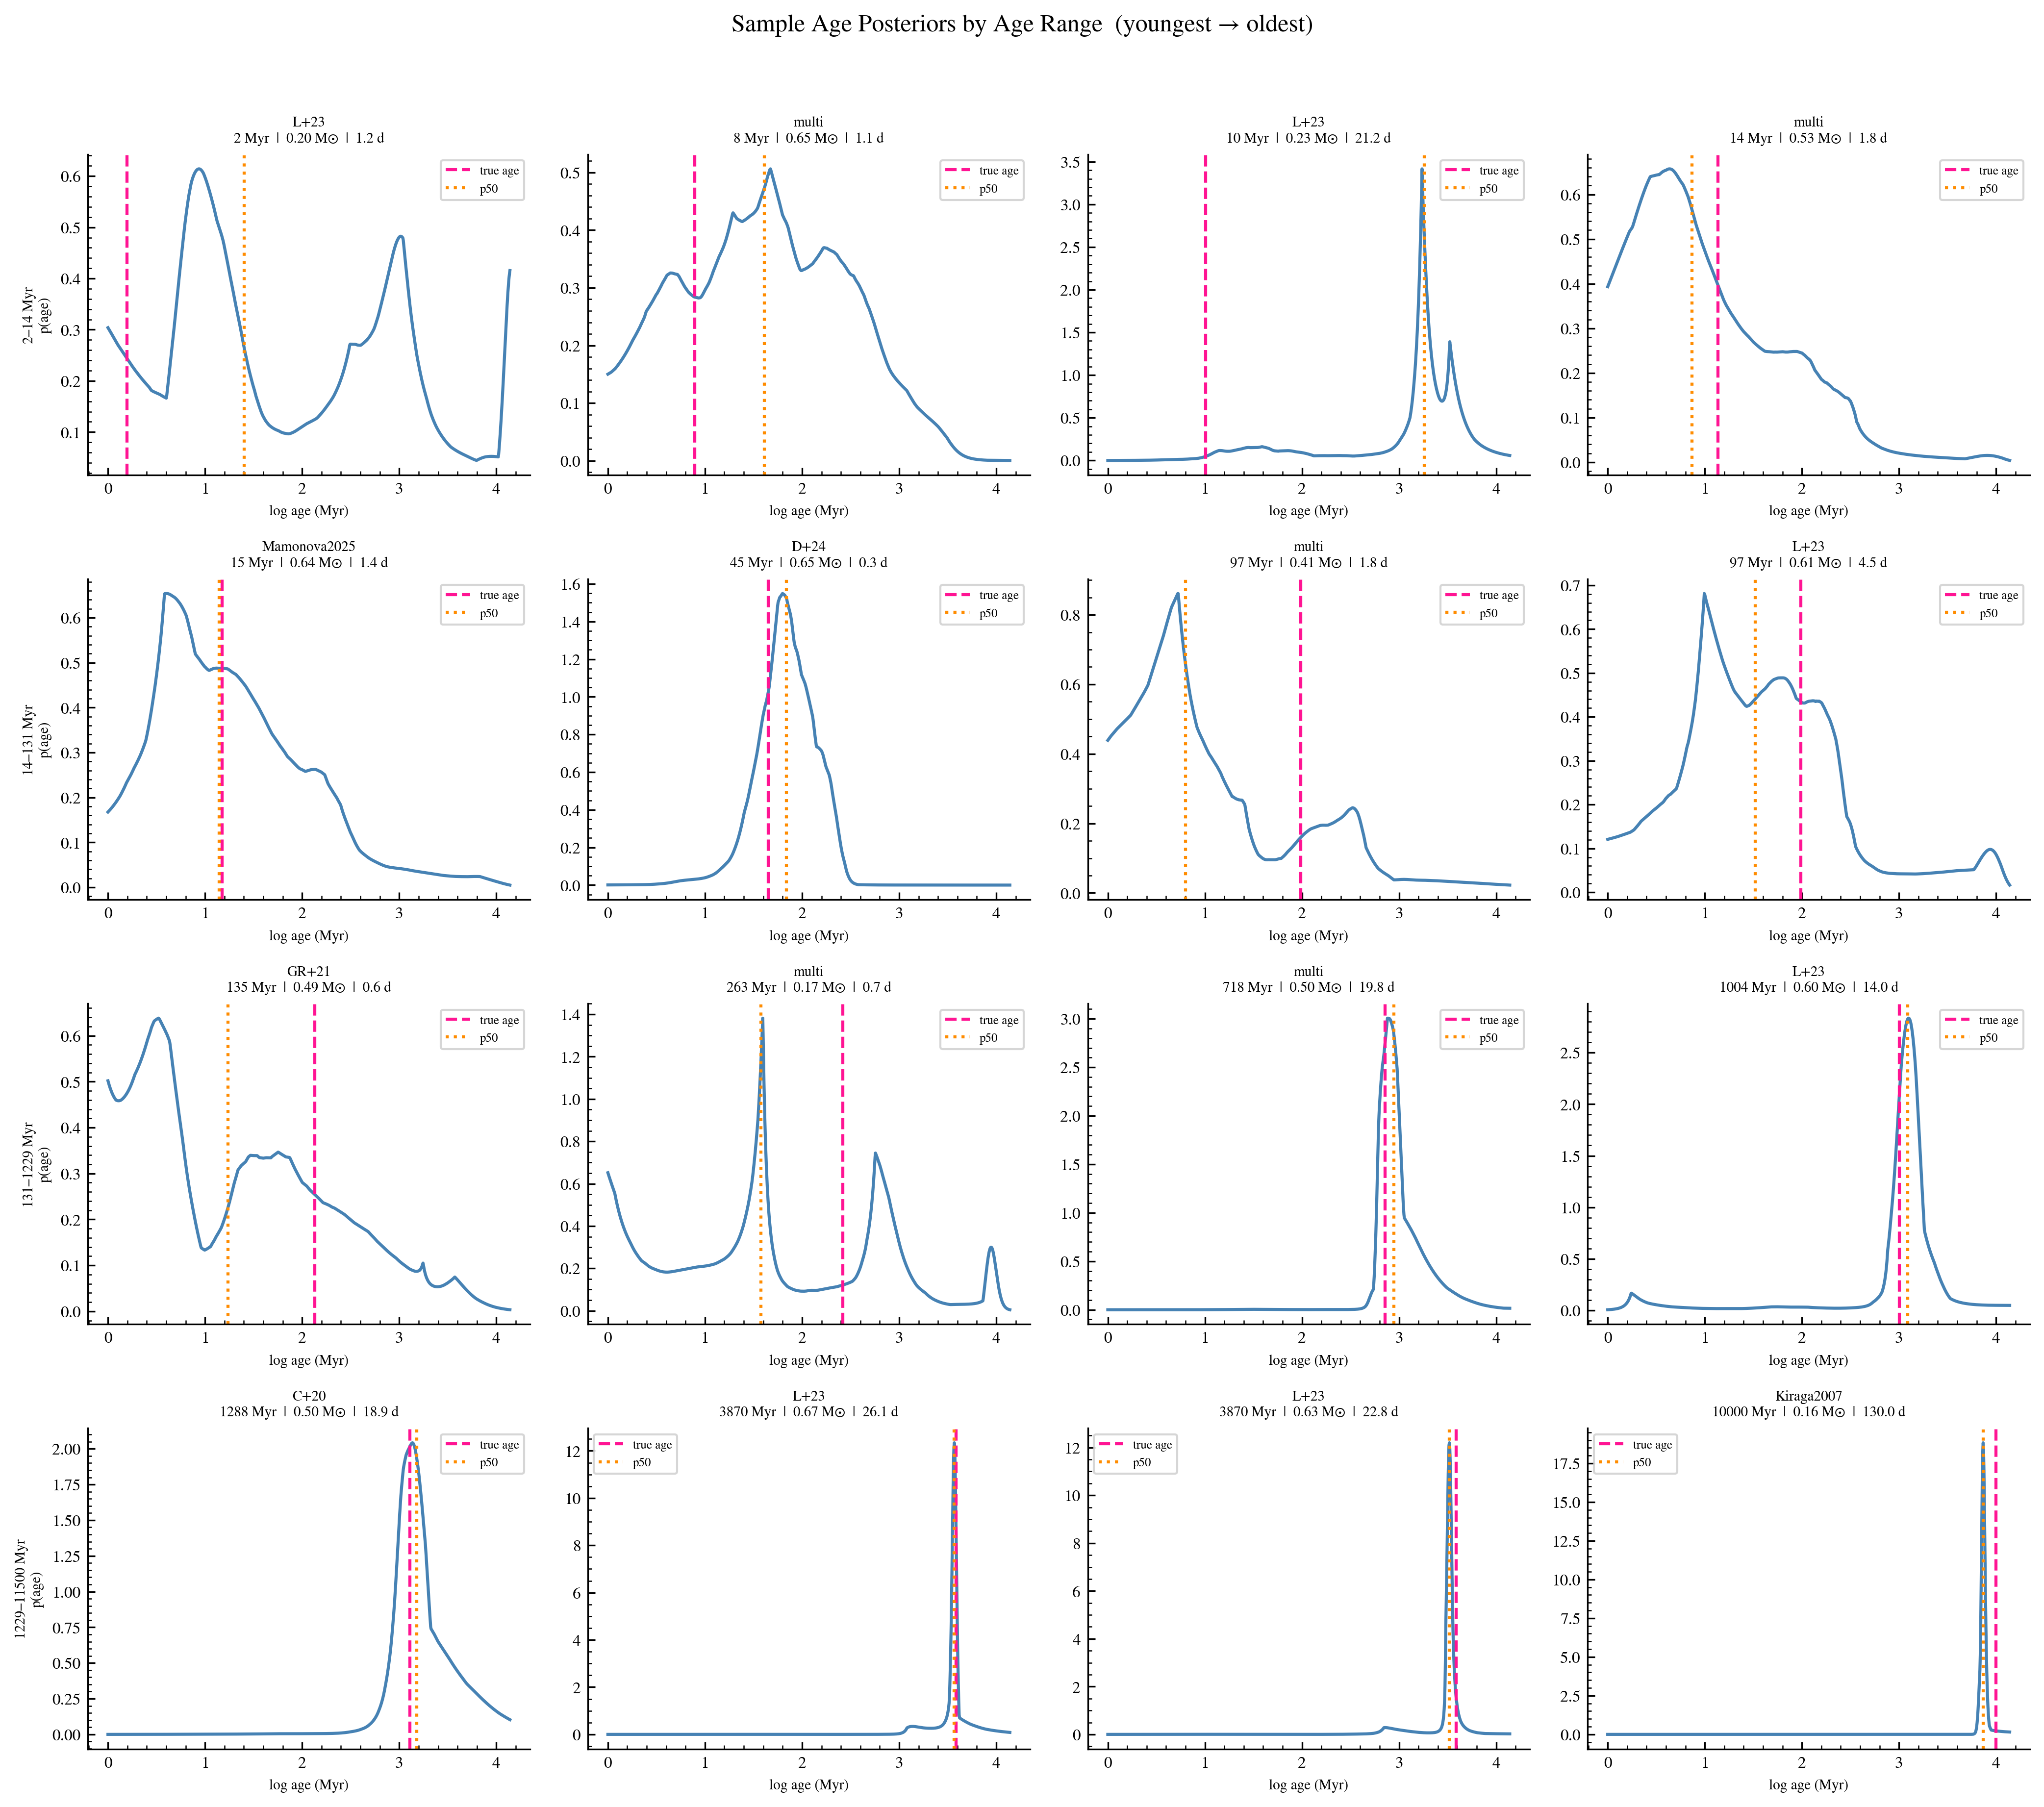

In [18]:
print('Posteriors shape:', posteriors_kfold.shape)
plot_posteriors_by_age(posteriors_kfold, LOGA_GRID, results_df, n_rows=4, n_cols=4)

## 6b. Posteriors near the fully convective boundary (0.3–0.4 M☉)

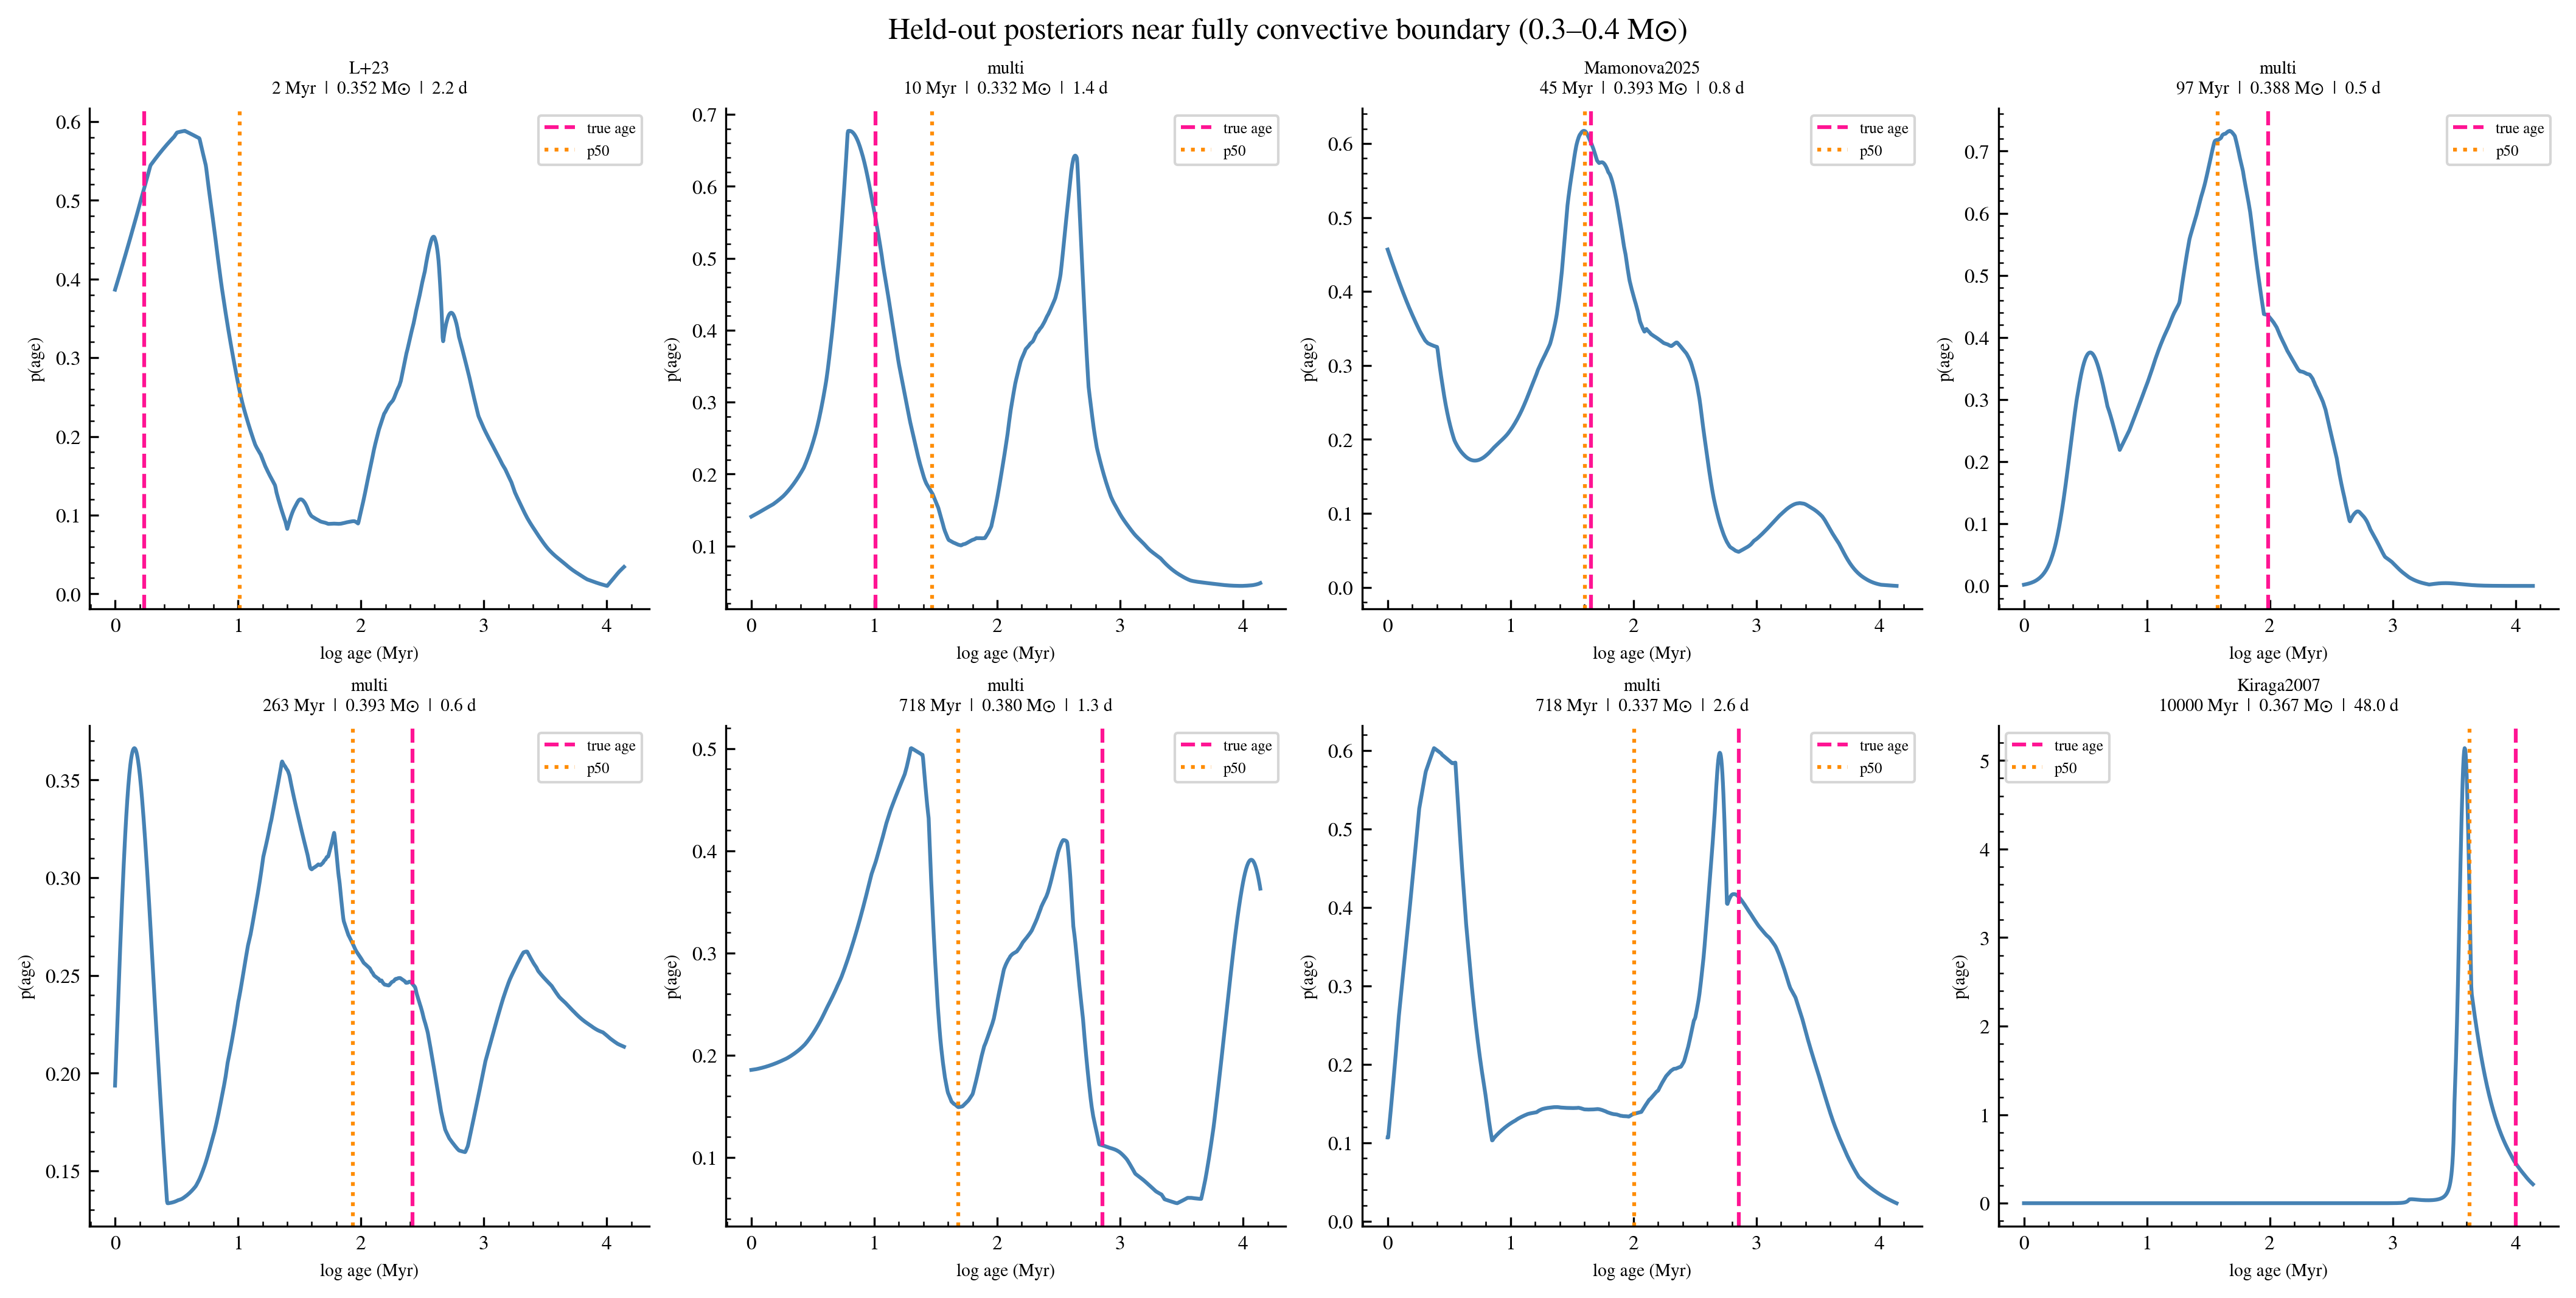

In [28]:
_field = {'MOCADB', 'Engle2023', 'LWRD', 'Pass2022'}

fc_mask = (results_df['mass_msun'] >= 0.3) & (results_df['mass_msun'] <= 0.4)
fc_df   = results_df[fc_mask].copy().reset_index(drop=True)
fc_pos  = np.where(fc_mask)[0]

is_cluster = ~fc_df['source_paper'].isin(_field)
pool_idx   = np.where(is_cluster)[0] if is_cluster.sum() >= 8 else np.arange(len(fc_df))
age_order  = pool_idx[np.argsort(fc_df.iloc[pool_idx]['log_age_myr'].values)]
pick       = age_order[np.linspace(0, len(age_order) - 1, 8, dtype=int)]

n_cols = 4
n_rows = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 7), layout='constrained')
axes = axes.flatten()
for ax, i in zip(axes, pick):
    row      = fc_df.iloc[i]
    post_idx = fc_pos[i]
    ax.plot(LOGA_GRID, posteriors_kfold[post_idx], color='steelblue', lw=1.5)
    ax.axvline(row['log_age_myr'], color='deeppink',  lw=1.5, ls='--', label='true age')
    ax.axvline(row['p50'],         color='darkorange', lw=1.5, ls=':',  label='p50')
    ax.set_title(
        f"{row['source_paper']}\n"
        f"{10**row['log_age_myr']:.0f} Myr  |  {row['mass_msun']:.3f} M☉  |  {row['prot_days']:.1f} d",
        fontsize=7,
    )
    ax.set_xlabel('log age (Myr)', fontsize=7)
    ax.set_ylabel('p(age)', fontsize=7)
    ax.legend(fontsize=6)
fig.suptitle('Held-out posteriors near fully convective boundary (0.3–0.4 M☉)')
plt.show()

## 6c. Posteriors for young slow rotators (age < 300 Myr, P_rot > 10 d)

Young slow rotators found: 115


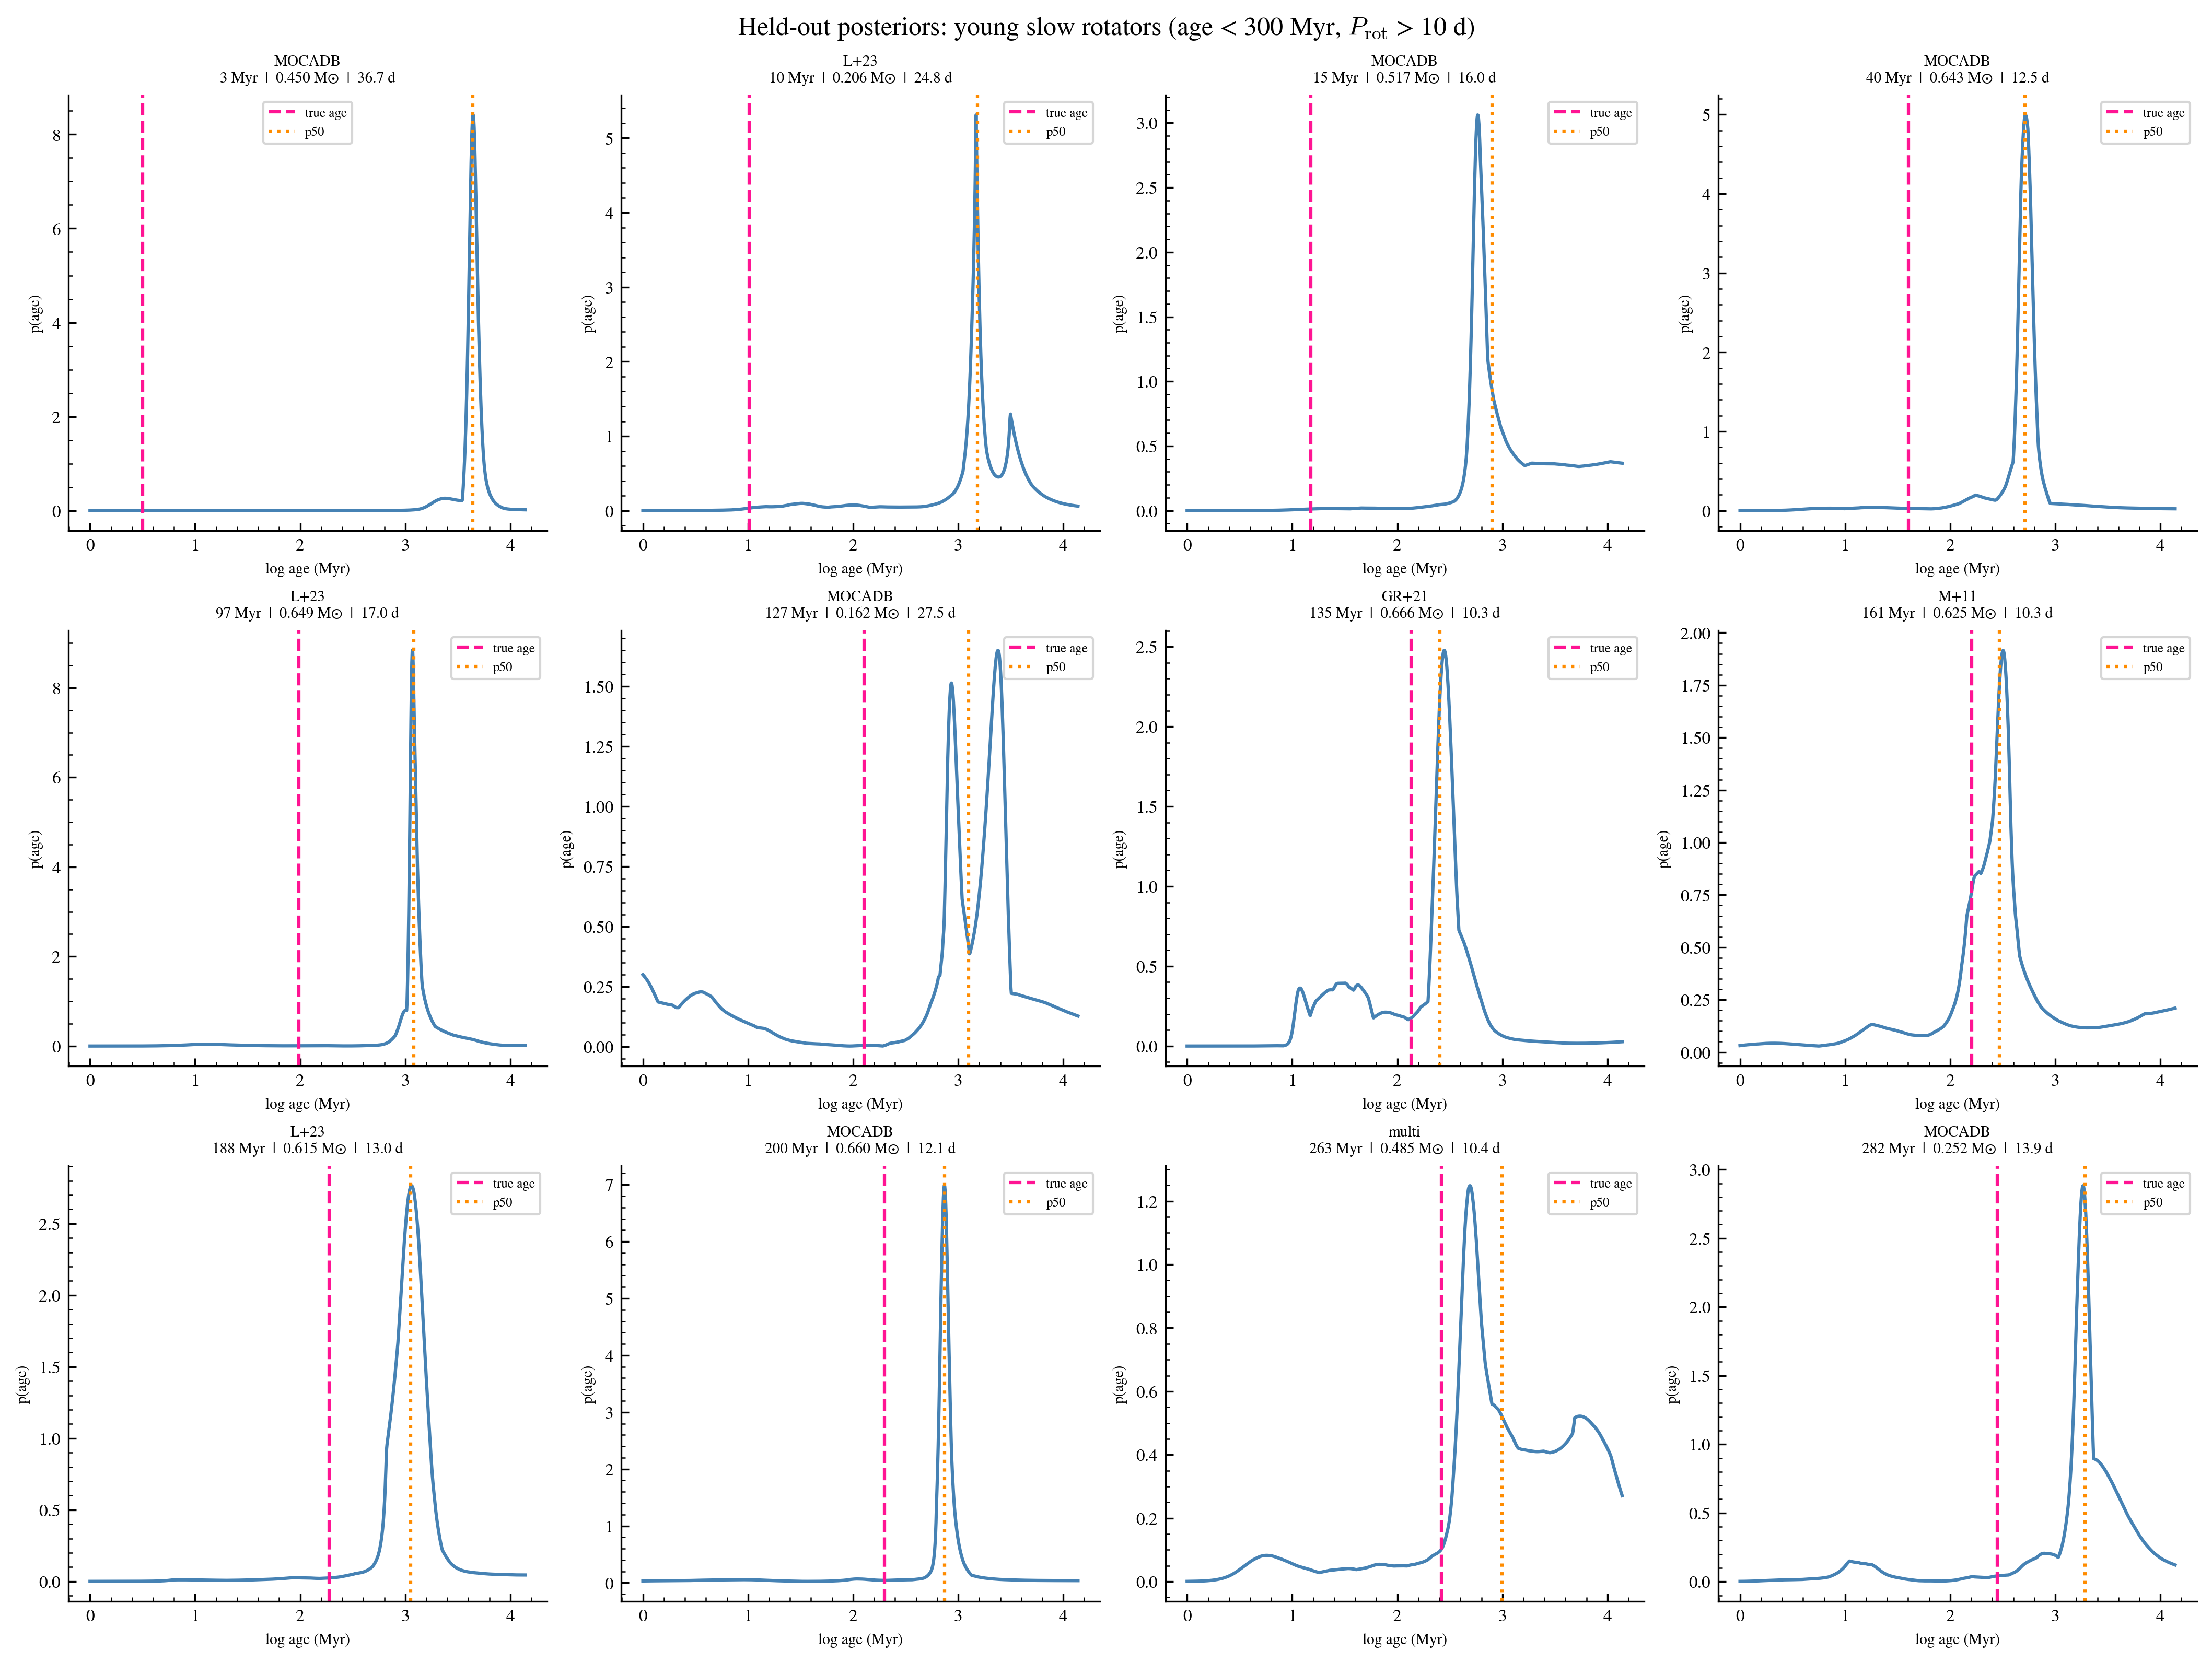

In [43]:
yr_mask = (results_df['log_age_myr'] < np.log10(300)) & (results_df['prot_days'] > 10)
yr_df   = results_df[yr_mask].copy().reset_index(drop=True)
yr_pos  = np.where(yr_mask)[0]

print(f'Young slow rotators found: {len(yr_df)}')

n_pick = min(12, len(yr_df))
age_order = np.argsort(yr_df['log_age_myr'].values)
pick      = age_order[np.linspace(0, len(age_order) - 1, n_pick, dtype=int)]

n_cols = 4
n_rows = int(np.ceil(n_pick / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5), layout='constrained')
axes = axes.flatten()
for ax, i in zip(axes, pick):
    row      = yr_df.iloc[i]
    post_idx = yr_pos[i]
    ax.plot(LOGA_GRID, posteriors_kfold[post_idx], color='steelblue', lw=1.5)
    ax.axvline(row['log_age_myr'], color='deeppink',  lw=1.5, ls='--', label='true age')
    ax.axvline(row['p50'],         color='darkorange', lw=1.5, ls=':',  label='p50')
    ax.set_title(
        f"{row['source_paper']}\n"
        f"{10**row['log_age_myr']:.0f} Myr  |  {row['mass_msun']:.3f} M☉  |  {row['prot_days']:.1f} d",
        fontsize=7,
    )
    ax.set_xlabel('log age (Myr)', fontsize=7)
    ax.set_ylabel('p(age)', fontsize=7)
    ax.legend(fontsize=6)
for ax in axes[n_pick:]:
    ax.set_visible(False)
fig.suptitle('Held-out posteriors: young slow rotators (age < 300 Myr, $P_\\mathrm{rot}$ > 10 d)')
plt.show()

## 6d. Posteriors for low-mass fast rotators (M < 0.4 M☉, P_rot < 5 d)

Low-mass fast rotators: 1963
Age range: 2 – 4981 Myr


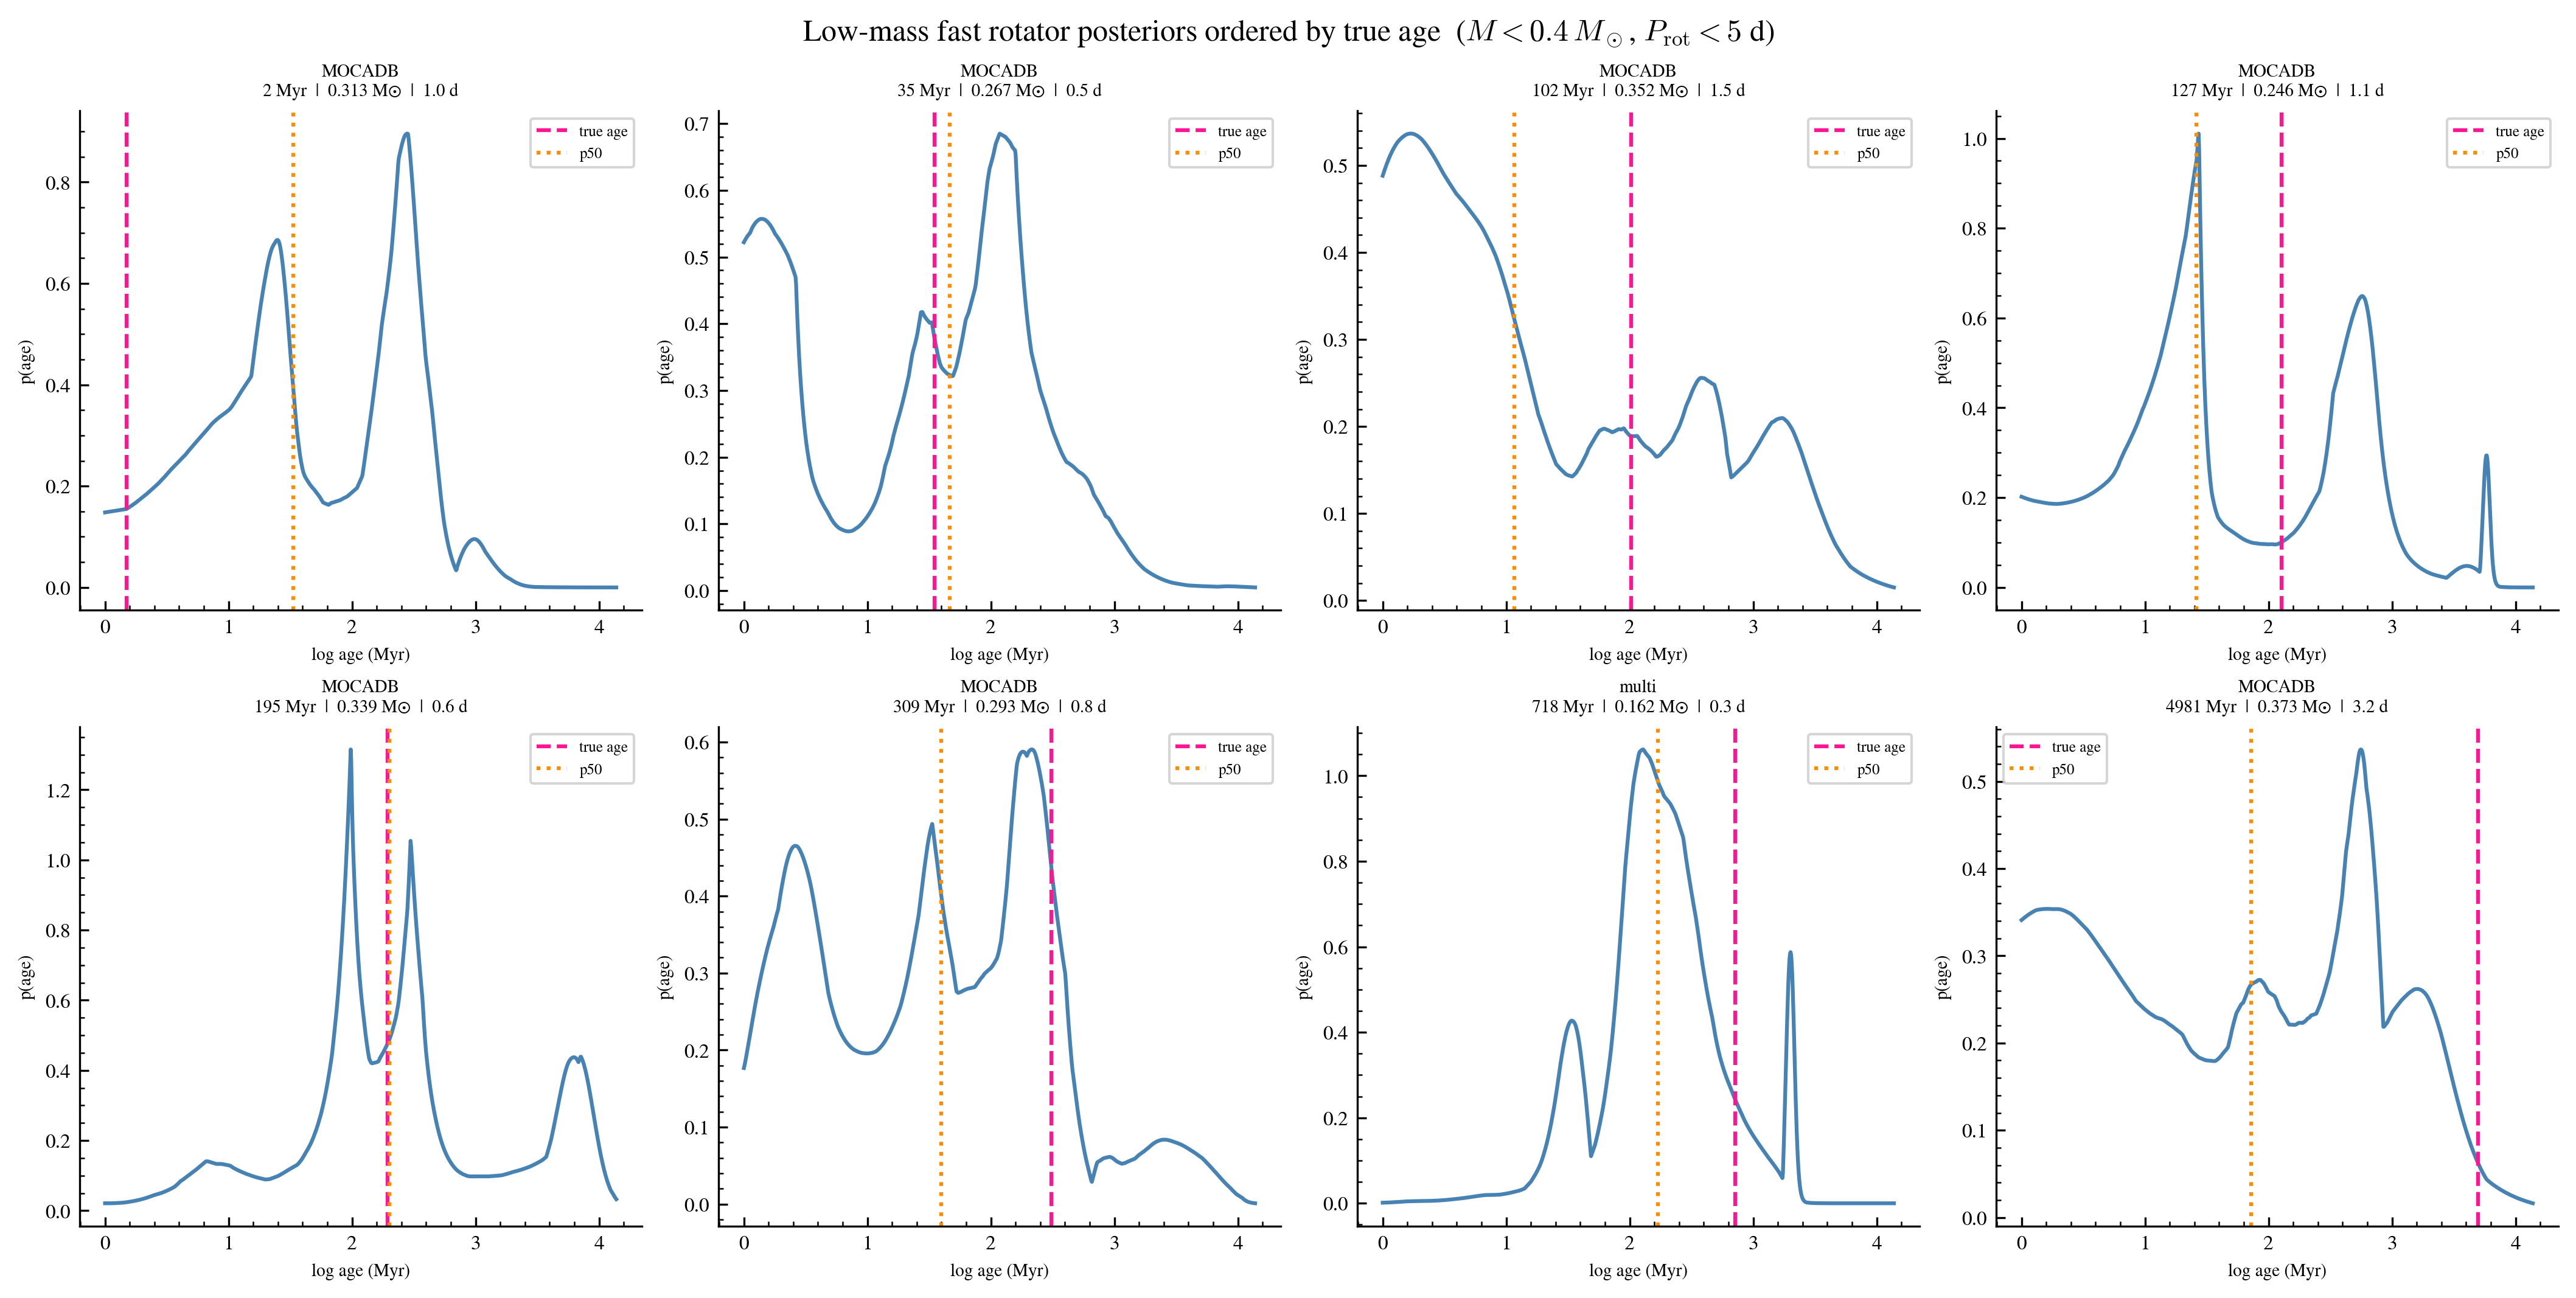

In [45]:
lmfr_mask = (results_df['mass_msun'] < 0.4) & (results_df['prot_days'] < 5)
lmfr_df   = results_df[lmfr_mask].copy().reset_index(drop=True)
lmfr_pos  = np.where(lmfr_mask)[0]

print(f'Low-mass fast rotators: {len(lmfr_df)}')
print(f'Age range: {10**lmfr_df["log_age_myr"].min():.0f} – {10**lmfr_df["log_age_myr"].max():.0f} Myr')

# Pick 8 evenly spaced across the true age range
age_order = np.argsort(lmfr_df['log_age_myr'].values)
pick      = age_order[np.linspace(0, len(age_order) - 1, 8, dtype=int)]

n_cols, n_rows = 4, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 7), layout='constrained')
axes = axes.flatten()
for ax, i in zip(axes, pick):
    row      = lmfr_df.iloc[i]
    post_idx = lmfr_pos[i]
    ax.plot(LOGA_GRID, posteriors_kfold[post_idx], color='steelblue', lw=1.5)
    ax.axvline(row['log_age_myr'], color='deeppink',  lw=1.5, ls='--', label='true age')
    ax.axvline(row['p50'],         color='darkorange', lw=1.5, ls=':',  label='p50')
    ax.set_title(
        f"{row['source_paper']}\n"
        f"{10**row['log_age_myr']:.0f} Myr  |  {row['mass_msun']:.3f} M☉  |  {row['prot_days']:.1f} d",
        fontsize=7,
    )
    ax.set_xlabel('log age (Myr)', fontsize=7)
    ax.set_ylabel('p(age)', fontsize=7)
    ax.legend(fontsize=6)
fig.suptitle('Low-mass fast rotator posteriors ordered by true age  ($M < 0.4\\,M_\\odot$, $P_\\mathrm{rot} < 5$ d)')
plt.show()

## 7. $P(P_\mathrm{rot}\,|\,\mathrm{age,\,mass})$ heatmap per cluster

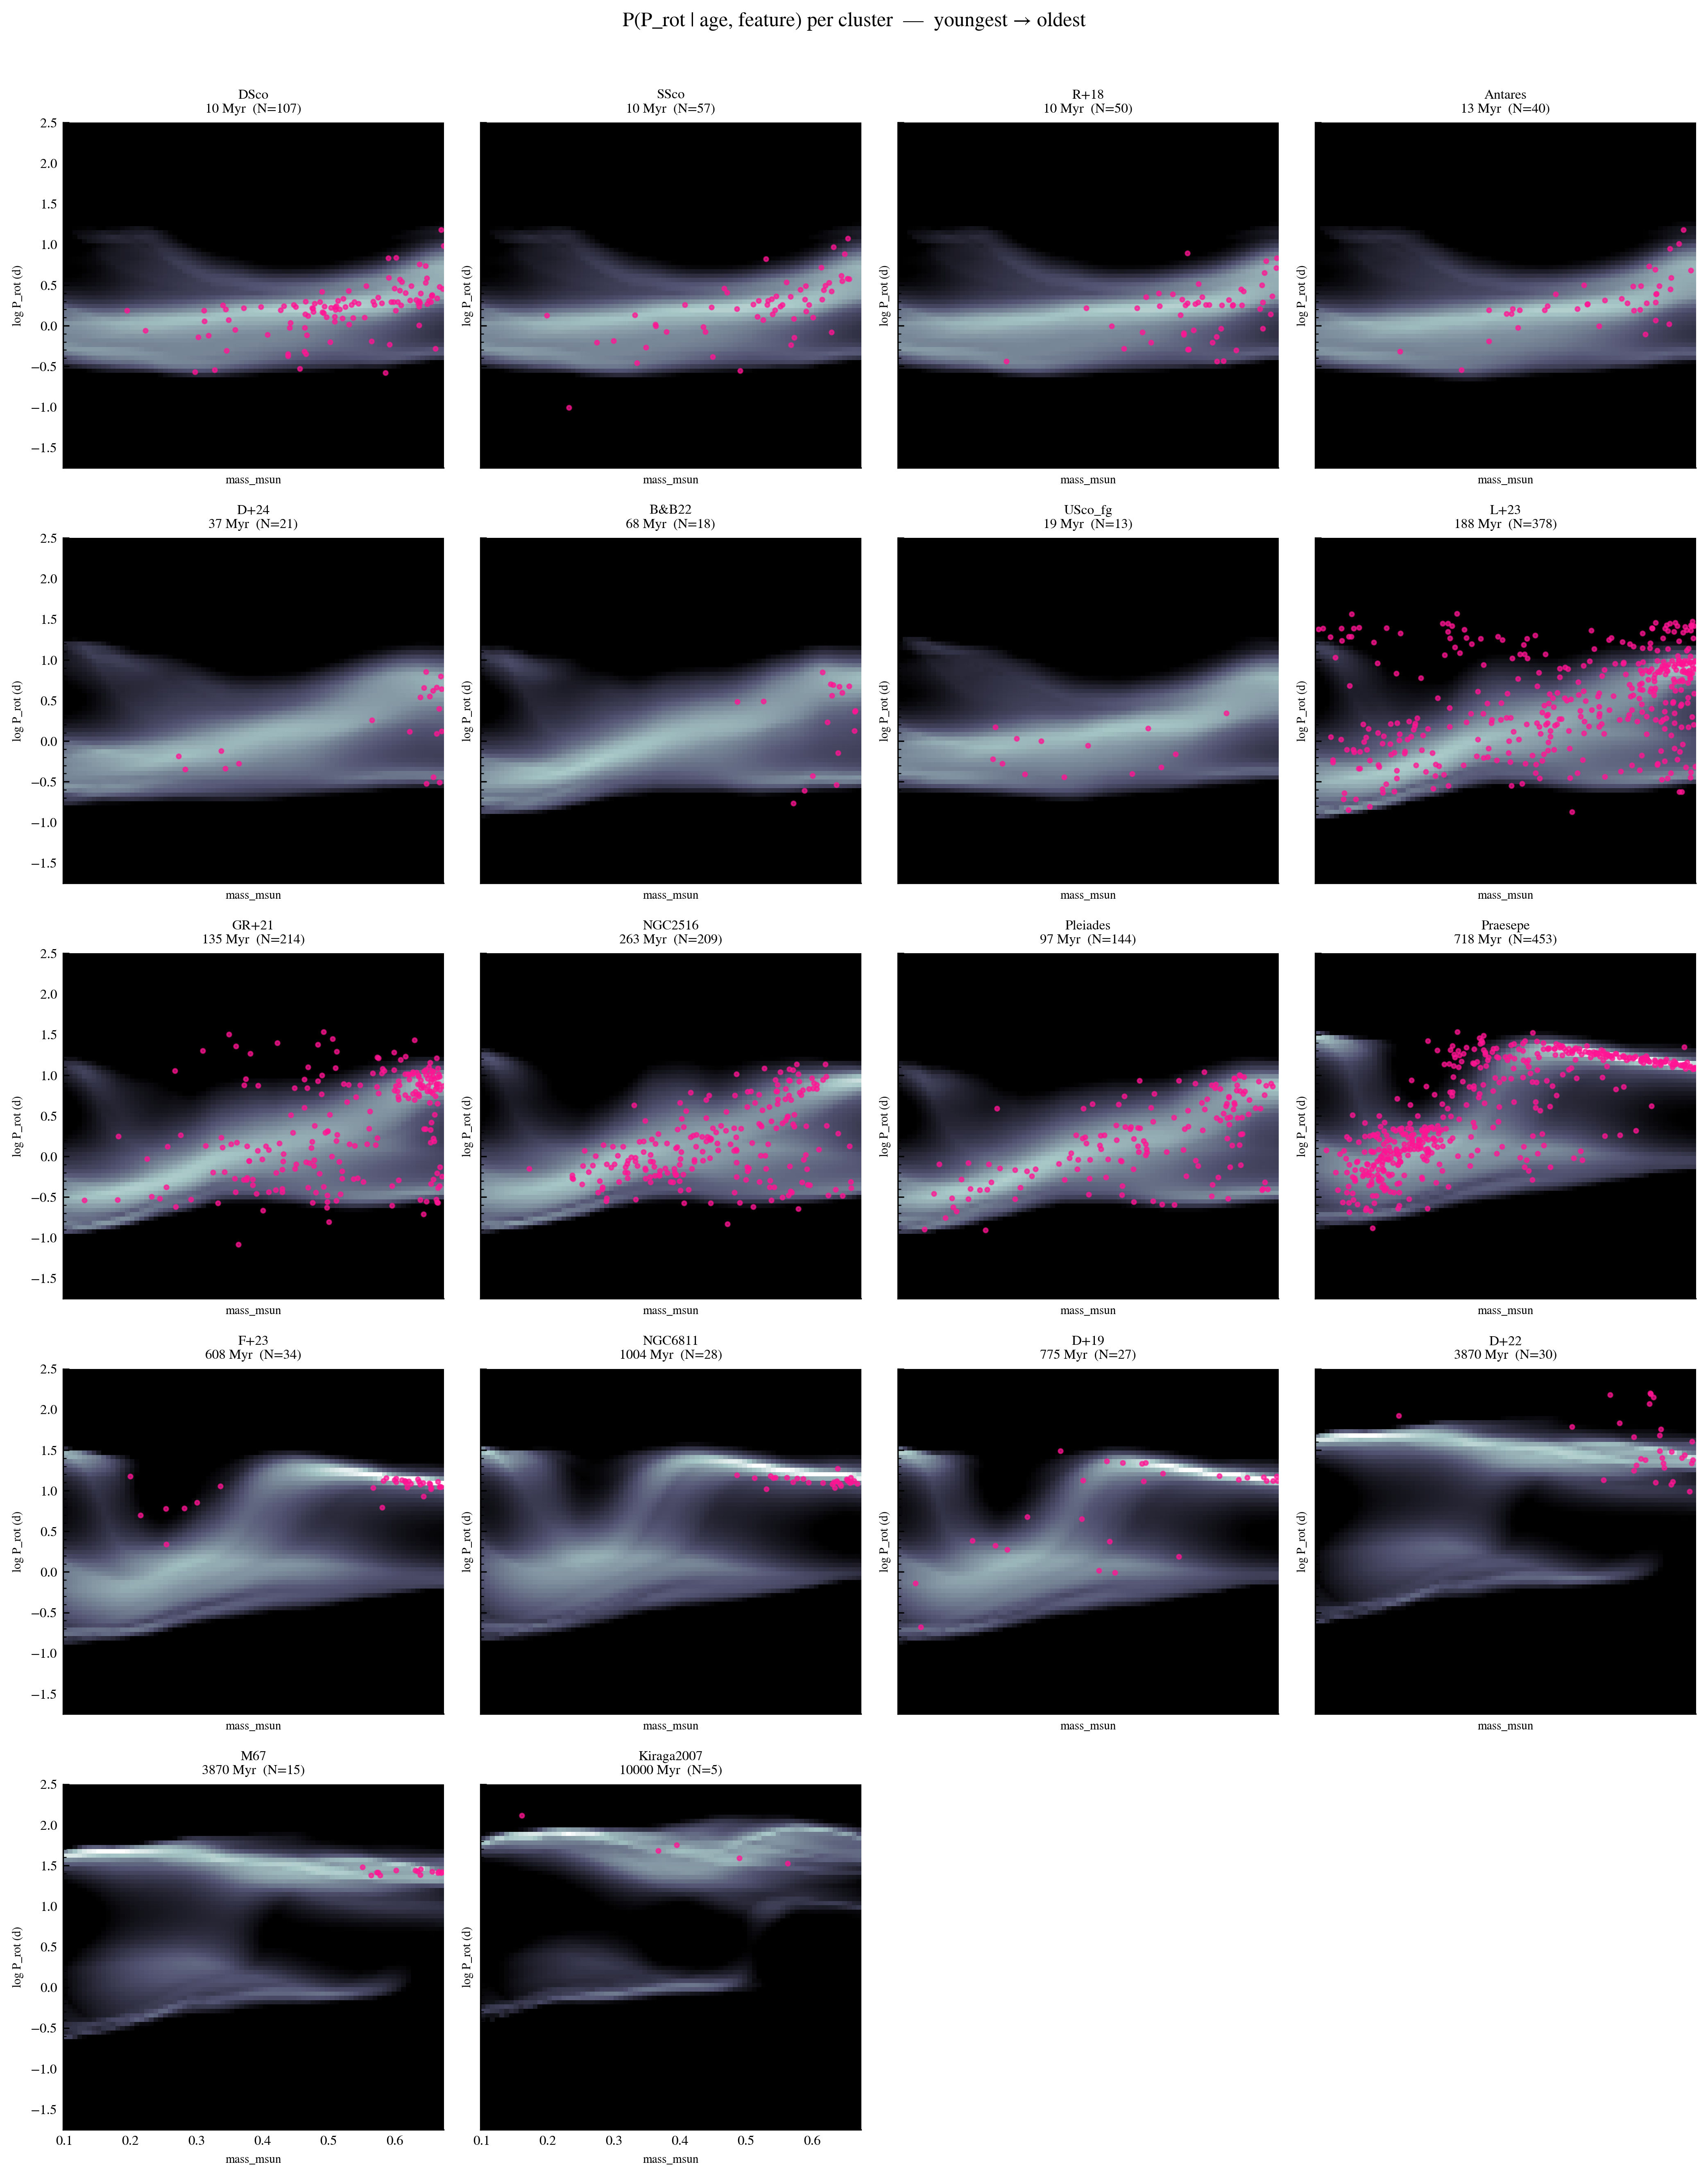

In [25]:
import importlib, training.plots, training.report
importlib.reload(training.plots)
importlib.reload(training.report)
from training.report import prot_space_report

prot_space_report(fold_flows, df, COND_COLS, fold_scalers)

## 8. Summary statistics

In [ ]:
print('=== Mass Model validation summary ===')
print(f'N stars evaluated : {len(results_df)}')
print(f'Median residual   : {results_df["residual_dex"].median():.3f} dex')
print(f'Median precision  : {(results_df["p84"] - results_df["p16"]).median():.3f} dex')
print(f'% within 0.3 dex  : {(results_df["residual_dex"].abs() < 0.3).mean()*100:.1f}%')
results_df.groupby('fold')[['residual_dex']].agg(['median', 'std'])

=== Mass Model — K-fold validation summary ===
N stars evaluated : 6128
Median residual   : -0.255 dex
Median precision  : 1.647 dex
% within 0.3 dex  : 37.3%


residual_dex          
           median       std
fold                       
0       -0.244785  0.726967
1       -0.270316  0.705227
2       -0.265194  0.705675
3       -0.211228  0.729184
4       -0.284240  0.684516

In [21]:
valid = results_df[['log_age_myr', 'p16', 'p84']].notna().all(axis=1)
inside_68 = (
    valid
    & (results_df['log_age_myr'] >= results_df['p16'])
    & (results_df['log_age_myr'] <= results_df['p84'])
)

n         = int(valid.sum())
cover68   = inside_68[valid].mean()
expected  = 0.68
binom_sig = np.sqrt(expected * (1 - expected) / n)
off_sig   = (cover68 - expected) / binom_sig

print('=== 68% posterior coverage check ===')
print(f'N valid stars       : {n}')
print(f'Observed coverage   : {cover68:.3f} ({cover68*100:.1f}%)')
print(f'Expected coverage   : {expected:.3f} +/- {binom_sig:.3f} (binomial 1-sigma)')
print(f'Coverage offset     : {off_sig:+.2f} sigma')
if cover68 < expected - binom_sig:
    print('Interpretation      : under-covering; posteriors too narrow / overconfident.')
elif cover68 > expected + binom_sig:
    print('Interpretation      : over-covering; posteriors too broad / conservative.')
else:
    print('Interpretation      : close to nominal 68% calibration.')

=== 68% posterior coverage check ===
N valid stars       : 6128
Observed coverage   : 0.746 (74.6%)
Expected coverage   : 0.680 +/- 0.006 (binomial 1-sigma)
Coverage offset     : +11.04 sigma
Interpretation      : over-covering; posteriors too broad / conservative.


## 9. Save

In [22]:
import os
os.makedirs('../../outputs/mass_model', exist_ok=True)

results_df.to_csv('../../outputs/mass_model/results.csv', index=False)
np.save('../../outputs/mass_model/posteriors_kfold.npy', posteriors_kfold)
np.save('../../outputs/mass_model/loss_curves.npy',
        np.array(loss_curves, dtype=object), allow_pickle=True)

for i, (flow, scaler) in enumerate(zip(fold_flows, fold_scalers)):
    torch.save(flow.state_dict(), f'../../outputs/mass_model/fold{i}_flow.pt')
    with open(f'../../outputs/mass_model/fold{i}_scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)

print('Saved to outputs/mass_model/')

Saved to outputs/mass_model/
